In [1]:
from __future__ import annotations

import json
import math
import re
import warnings

from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display


# ---------------------------------------------------------------------
# Project paths
# ---------------------------------------------------------------------

THESIS_DIR = Path(
    "/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS"
)

OUTPUT_ROOT = (
    THESIS_DIR
    / "outputs"
    / "chapter4"
)

POSTHOC_DIR = (
    OUTPUT_ROOT
    / "posthoc_final"
)

FINAL_DIR = (
    OUTPUT_ROOT
    / "line_location_final"
)

TABLE_DIR = FINAL_DIR / "tables"
FIGURE_DIR = FINAL_DIR / "figures"
AUDIT_DIR = FINAL_DIR / "audit"
LATEX_DIR = FINAL_DIR / "latex"

for directory in [
    FINAL_DIR,
    TABLE_DIR,
    FIGURE_DIR,
    AUDIT_DIR,
    LATEX_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


# ---------------------------------------------------------------------
# Validated post-hoc inputs
# ---------------------------------------------------------------------

INTEGRITY_PATH = (
    POSTHOC_DIR
    / "posthoc_integrity_audit.json"
)

UNIFIED_EVENT_PATH = (
    POSTHOC_DIR
    / "posthoc_unified_event_predictions.parquet"
)

UNIFIED_WINDOW_PATH = (
    POSTHOC_DIR
    / "posthoc_unified_window_predictions.parquet"
)


# ---------------------------------------------------------------------
# Final one-ended 110 kV model-input prior
# ---------------------------------------------------------------------

MODEL_INPUT_110_PATH = (
    OUTPUT_ROOT
    / "model_inputs"
    / "caseaware_bestmae"
    / "20260717_234516"
    / (
        "kol_operator_features_hv_double_line_110kv_"
        "line_case_bestmae_fullcohort_all_fault_start_"
        "model_input.csv"
    )
)

FINAL_PRIOR_COLUMN_110 = (
    "d_110kv_line_case_bestmae_input_pct"
)


# ---------------------------------------------------------------------
# Experiment and cohort settings
# ---------------------------------------------------------------------

EXPERIMENT_ORDER = [
    "C90-1E",
    "L90-1E",
    "C110-1E",
    "L110-1E",
    "C90-2E",
    "L90-2E",
    "C110-2E",
    "L110-2E",
]

LINE_ORDER = {
    90: [
        "Line_1_2_a",
        "Line_1_2_b",
        "Line_2_3_a",
        "Line_2_3_b",
    ],
    110: [
        "MainLn1-2A",
        "MainLn1-2B",
        "MainLn2-3A",
        "MainLn2-3B",
    ],
}

LOCATION_BIN_EDGES = [
    0,
    10,
    20,
    30,
    40,
    50,
    60,
    70,
    80,
    90,
    100.000001,
]

LOCATION_BIN_LABELS = [
    "00-10",
    "10-20",
    "20-30",
    "30-40",
    "40-50",
    "50-60",
    "60-70",
    "70-80",
    "80-90",
    "90-100",
]


# ---------------------------------------------------------------------
# Fixed line-dependent terminal convention
# ---------------------------------------------------------------------

EXPECTED_LINE_TERMINAL = {
    "MainLn1-2A": "local",
    "MainLn1-2B": "local",
    "MainLn2-3A": "remote_direction_corrected",
    "MainLn2-3B": "remote_direction_corrected",
}


# ---------------------------------------------------------------------
# Scope of the terminal-convention audit
# ---------------------------------------------------------------------
#
# The fixed line-dependent terminal convention is verified strictly for:
#
#   3ph
#   LL
#   LLG
#
# SLG cases use separate case-aware rules. Their component provenance is
# inspected diagnostically, but an unresolved raw SLG component does not
# invalidate the fixed line-dependent terminal convention.
# ---------------------------------------------------------------------

LINE_TERMINAL_CASES = {
    "3ph",
    "ll_ab",
    "ll_bc",
    "ll_ca",
    "llg_ab",
    "llg_bc",
    "llg_ca",
}

SLG_CASES = {
    "slg_a",
    "slg_b",
    "slg_c",
}


# Historical SLG component hypotheses.
#
# These labels are used only to search for matching raw components. They
# are not considered verified unless the raw component numerically
# reconstructs the final prepared prior.
SLG_COMPONENT_HYPOTHESES = {
    "slg_a": "old",
    "slg_b": "both_mean",
    "slg_c": "both_mean",
}


# ---------------------------------------------------------------------
# Numerical tolerances
# ---------------------------------------------------------------------

EPS = 1e-8

# Cross-file float32/float64 comparison tolerance.
PRIOR_ALIGNMENT_TOLERANCE_PP = 1e-5

# A component must reproduce essentially every available row of a group.
MIN_EXACT_MATCH_RATE = 0.999999

# Fail only when a required 3ph/LL/LLG terminal-convention group fails.
STRICT_TERMINAL_AUDIT = True


print("Post-hoc input:", POSTHOC_DIR)
print("Output directory:", FINAL_DIR)
print("Final 110 kV prior input:", MODEL_INPUT_110_PATH)

print(
    "Required terminal-convention cases:",
    sorted(LINE_TERMINAL_CASES),
)

print(
    "Diagnostic SLG cases:",
    sorted(SLG_CASES),
)

Post-hoc input: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/posthoc_final
Output directory: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/line_location_final
Final 110 kV prior input: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/model_inputs/caseaware_bestmae/20260717_234516/kol_operator_features_hv_double_line_110kv_line_case_bestmae_fullcohort_all_fault_start_model_input.csv
Required terminal-convention cases: ['3ph', 'll_ab', 'll_bc', 'll_ca', 'llg_ab', 'llg_bc', 'llg_ca']
Diagnostic SLG cases: ['slg_a', 'slg_b', 'slg_c']


In [4]:
def normalize_column_name(
    value: str,
) -> str:
    value = str(value).strip().lower()

    value = re.sub(
        r"[^a-z0-9]+",
        "_",
        value,
    )

    return value.strip("_")


def normalized_lookup(
    frame: pd.DataFrame,
) -> dict[str, str]:
    return {
        normalize_column_name(column): column
        for column in frame.columns
    }


def find_column(
    frame: pd.DataFrame,
    candidates: Iterable[str],
    *,
    required: bool = False,
) -> str | None:
    lookup = normalized_lookup(frame)

    for candidate in candidates:
        normalized = normalize_column_name(
            candidate
        )

        if normalized in lookup:
            return lookup[normalized]

    if required:
        raise KeyError(
            "Required column not found.\n"
            f"Candidates: {list(candidates)}\n"
            f"Available: {list(frame.columns)}"
        )

    return None


def canonicalize_sample_ids(
    values: pd.Series,
) -> pd.Series:
    def convert(value: Any) -> str:
        if pd.isna(value):
            return "<missing>"

        text = str(value).strip()

        try:
            numeric = float(text)

            if (
                np.isfinite(numeric)
                and numeric.is_integer()
            ):
                return str(int(numeric))

        except Exception:
            pass

        return text

    return values.map(convert)


def finite_numeric(
    values: pd.Series,
) -> np.ndarray:
    numeric = pd.to_numeric(
        values,
        errors="coerce",
    ).to_numpy(dtype=float)

    return numeric[
        np.isfinite(numeric)
    ]


def write_latex_table(
    frame: pd.DataFrame,
    path: Path,
    *,
    float_format: str = "%.3f",
) -> None:
    latex = frame.to_latex(
        index=False,
        escape=True,
        na_rep="--",
        float_format=float_format,
    )

    path.write_text(
        latex,
        encoding="utf-8",
    )


def infer_voltage_kv(
    experiment_id: str,
) -> int:
    match = re.search(
        r"(90|110)",
        str(experiment_id),
    )

    if match is None:
        raise ValueError(
            f"Cannot infer voltage from "
            f"{experiment_id}"
        )

    return int(
        match.group(1)
    )


def infer_prior_view(
    experiment_id: str,
) -> str:
    match = re.search(
        r"-(1E|2E)$",
        str(experiment_id),
    )

    if match is None:
        raise ValueError(
            f"Cannot infer prior view from "
            f"{experiment_id}"
        )

    return match.group(1)


def infer_model_family(
    experiment_id: str,
) -> str:
    experiment_id = str(
        experiment_id
    )

    if experiment_id.startswith("C"):
        return "correction"

    if experiment_id.startswith("L"):
        return "bounded_learning"

    raise ValueError(
        f"Unknown model family: {experiment_id}"
    )


def support_class(
    support: int,
) -> str:
    if support >= 50:
        return "MAIN_TEXT_ELIGIBLE"

    if support >= 20:
        return "SUPPLEMENTARY_ONLY"

    return "DO_NOT_RANK"


def summarize_group(
    frame: pd.DataFrame,
) -> dict[str, Any]:
    prior_error = finite_numeric(
        frame["prior_abs_error_pp"]
    )

    model_error = finite_numeric(
        frame["model_abs_error_pp"]
    )

    if not (
        len(prior_error)
        == len(model_error)
        == len(frame)
    ):
        raise RuntimeError(
            "Non-finite errors found in subgroup."
        )

    gain = (
        prior_error
        - model_error
    )

    support = int(
        len(frame)
    )

    prior_mae = float(
        np.mean(prior_error)
    )

    model_mae = float(
        np.mean(model_error)
    )

    reduction = float(
        np.mean(gain)
    )

    if prior_mae > 0:
        relative_reduction = float(
            100.0
            * reduction
            / prior_mae
        )
    else:
        relative_reduction = np.nan

    return {
        "support": support,
        "support_class": (
            support_class(support)
        ),
        "prior_mae_pp": prior_mae,
        "model_mae_pp": model_mae,
        "mae_reduction_pp": reduction,
        "relative_mae_reduction_pct": (
            relative_reduction
        ),
        "model_rmse_pp": float(
            np.sqrt(
                np.mean(
                    np.square(
                        model_error
                    )
                )
            )
        ),
        "model_median_ae_pp": float(
            np.median(
                model_error
            )
        ),
        "model_p90_ae_pp": float(
            np.quantile(
                model_error,
                0.90,
            )
        ),
        "model_p95_ae_pp": float(
            np.quantile(
                model_error,
                0.95,
            )
        ),
        "model_p99_ae_pp": (
            float(
                np.quantile(
                    model_error,
                    0.99,
                )
            )
            if support >= 50
            else np.nan
        ),
        "model_max_ae_pp": float(
            np.max(
                model_error
            )
        ),
        "improved_rate_pct": float(
            100.0
            * np.mean(
                gain > EPS
            )
        ),
        "worsened_rate_pct": float(
            100.0
            * np.mean(
                gain < -EPS
            )
        ),
        "unchanged_rate_pct": float(
            100.0
            * np.mean(
                np.abs(gain)
                <= EPS
            )
        ),
    }


def classify_component_column(
    column_name: str,
) -> str | None:
    name = normalize_column_name(
        column_name
    )

    if (
        "remote_flipped" in name
        or "remote_flip" in name
        or "direction_corrected" in name
    ):
        return "remote_flipped"

    if (
        "both_mean" in name
        or "both_side_mean" in name
        or "local_remote_mean" in name
        or "remote_local_mean" in name
    ):
        return "both_mean"

    if (
        "takagi_local" in name
        or (
            "local" in name
            and "takagi" in name
            and "remote" not in name
        )
    ):
        return "local"

    if (
        "takagi_remote" in name
        or (
            "remote" in name
            and "takagi" in name
        )
    ):
        return "remote_raw"

    if (
        "old_prior" in name
        or "old_distance" in name
        or name.startswith("d_old")
        or "impedance_old" in name
        or "original_prior" in name
    ):
        return "old"

    return None


def possible_transforms(
    component_kind: str,
) -> list[str]:
    if component_kind == "remote_raw":
        return [
            "hundred_minus",
            "hundred_minus_then_clip",
        ]

    return [
        "identity",
        "clip_0_100",
    ]


def apply_transform(
    values: pd.Series,
    transform: str,
) -> pd.Series:
    numeric = pd.to_numeric(
        values,
        errors="coerce",
    )

    if transform == "identity":
        return numeric

    if transform == "clip_0_100":
        return numeric.clip(
            lower=0.0,
            upper=100.0,
        )

    if transform == "hundred_minus":
        return 100.0 - numeric

    if transform == (
        "hundred_minus_then_clip"
    ):
        return (
            100.0
            - numeric
        ).clip(
            lower=0.0,
            upper=100.0,
        )

    raise ValueError(
        f"Unknown transform: {transform}"
    )


def scale_candidate_to_percent(
    candidate: pd.Series,
    reference: pd.Series,
) -> tuple[pd.Series, str]:
    candidate_numeric = pd.to_numeric(
        candidate,
        errors="coerce",
    )

    reference_numeric = pd.to_numeric(
        reference,
        errors="coerce",
    )

    candidate_finite = candidate_numeric[
        np.isfinite(candidate_numeric)
    ]

    reference_finite = reference_numeric[
        np.isfinite(reference_numeric)
    ]

    if (
        candidate_finite.empty
        or reference_finite.empty
    ):
        return candidate_numeric, "unknown"

    candidate_q99 = float(
        candidate_finite.abs().quantile(
            0.99
        )
    )

    reference_q99 = float(
        reference_finite.abs().quantile(
            0.99
        )
    )

    if (
        candidate_q99 <= 1.5
        and reference_q99 > 1.5
    ):
        return (
            candidate_numeric * 100.0,
            "fraction_to_percent",
        )

    return (
        candidate_numeric,
        "already_percent",
    )

In [5]:
for required_path in [
    INTEGRITY_PATH,
    UNIFIED_EVENT_PATH,
    UNIFIED_WINDOW_PATH,
]:
    if not required_path.exists():
        raise FileNotFoundError(
            required_path
        )


with INTEGRITY_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    integrity_payload = json.load(file)


if integrity_payload.get(
    "overall_status"
) != "PASS":
    raise RuntimeError(
        "The mandatory post-hoc integrity "
        "audit did not pass."
    )


event_data = pd.read_parquet(
    UNIFIED_EVENT_PATH
)

window_data = pd.read_parquet(
    UNIFIED_WINDOW_PATH
)


required_event_columns = [
    "experiment_id",
    "sample_id",
    "fold",
    "y_true_pct",
    "y_prior_pct",
    "y_pred_pct",
    "prior_abs_error_pp",
    "model_abs_error_pp",
    "y_fault_line",
    "case",
]

missing_columns = [
    column
    for column in required_event_columns
    if column not in event_data.columns
]

if missing_columns:
    raise KeyError(
        "Unified event table is missing: "
        f"{missing_columns}"
    )


event_data = event_data.loc[
    event_data["experiment_id"].isin(
        EXPERIMENT_ORDER
    )
].copy()


event_data["sample_id"] = (
    canonicalize_sample_ids(
        event_data["sample_id"]
    )
)

event_data["voltage_kv"] = (
    event_data["experiment_id"]
    .map(infer_voltage_kv)
)

event_data["prior_view"] = (
    event_data["experiment_id"]
    .map(infer_prior_view)
)

event_data["model_family"] = (
    event_data["experiment_id"]
    .map(infer_model_family)
)

event_data[
    "fault_location_pct"
] = pd.to_numeric(
    event_data["y_true_pct"],
    errors="coerce",
)

event_data[
    "location_bin_10pp"
] = pd.cut(
    event_data[
        "fault_location_pct"
    ],
    bins=LOCATION_BIN_EDGES,
    labels=LOCATION_BIN_LABELS,
    right=False,
    include_lowest=True,
)


if event_data[
    "location_bin_10pp"
].isna().any():
    invalid_locations = (
        event_data.loc[
            event_data[
                "location_bin_10pp"
            ].isna(),
            [
                "experiment_id",
                "sample_id",
                "fault_location_pct",
            ],
        ]
    )

    raise RuntimeError(
        "Fault locations outside the expected "
        "physical range were found:\n"
        f"{invalid_locations.head()}"
    )


experiment_counts = (
    event_data.groupby(
        "experiment_id"
    )
    .agg(
        rows=(
            "sample_id",
            "size",
        ),
        unique_events=(
            "sample_id",
            "nunique",
        ),
        unique_lines=(
            "y_fault_line",
            "nunique",
        ),
        unique_locations=(
            "fault_location_pct",
            "nunique",
        ),
    )
    .reindex(EXPERIMENT_ORDER)
)


expected_counts = {
    "C90-1E": 9022,
    "L90-1E": 9022,
    "C110-1E": 912,
    "L110-1E": 912,
    "C90-2E": 9022,
    "L90-2E": 9022,
    "C110-2E": 912,
    "L110-2E": 912,
}


for experiment_id, expected_count in (
    expected_counts.items()
):
    observed = int(
        experiment_counts.loc[
            experiment_id,
            "rows",
        ]
    )

    unique_observed = int(
        experiment_counts.loc[
            experiment_id,
            "unique_events",
        ]
    )

    if not (
        observed
        == unique_observed
        == expected_count
    ):
        raise RuntimeError(
            f"{experiment_id}: expected "
            f"{expected_count} unique event rows, "
            f"observed {observed} rows and "
            f"{unique_observed} unique events."
        )


exact_locations_110 = sorted(
    event_data.loc[
        event_data["voltage_kv"] == 110,
        "fault_location_pct",
    ]
    .dropna()
    .unique()
    .tolist()
)


print("Integrity status: PASS")
print("Event rows:", f"{len(event_data):,}")
print(
    "Actual 110 kV location values:",
    exact_locations_110,
)

display(experiment_counts)

Integrity status: PASS
Event rows: 39,736
Actual 110 kV location values: [0.9999999776482582, 20.000000298023224, 50.0, 80.0000011920929, 99.00000095367432]


,rows,unique_events,unique_lines,unique_locations
experiment_id,,,,
C90-1E,9022,9022,4,9017
L90-1E,9022,9022,4,9017
C110-1E,912,912,4,5
L110-1E,912,912,4,5
C90-2E,9022,9022,4,9017
L90-2E,9022,9022,4,9017
C110-2E,912,912,4,5
L110-2E,912,912,4,5


In [6]:
line_rows = []


for (
    experiment_id,
    line_name,
), subgroup in event_data.groupby(
    [
        "experiment_id",
        "y_fault_line",
    ],
    sort=False,
    observed=False,
):
    line_rows.append(
        {
            "experiment_id": (
                experiment_id
            ),
            "voltage_kv": int(
                subgroup[
                    "voltage_kv"
                ].iloc[0]
            ),
            "prior_view": subgroup[
                "prior_view"
            ].iloc[0],
            "model_family": subgroup[
                "model_family"
            ].iloc[0],
            "faulted_line": str(
                line_name
            ),
            **summarize_group(
                subgroup
            ),
        }
    )


linewise_metrics = pd.DataFrame(
    line_rows
)


experiment_order_map = {
    experiment_id: index
    for index, experiment_id
    in enumerate(EXPERIMENT_ORDER)
}


line_order_map = {
    line_name: index
    for voltage_lines in (
        LINE_ORDER.values()
    )
    for index, line_name
    in enumerate(voltage_lines)
}


linewise_metrics[
    "_experiment_order"
] = linewise_metrics[
    "experiment_id"
].map(
    experiment_order_map
)

linewise_metrics[
    "_line_order"
] = linewise_metrics[
    "faulted_line"
].map(
    line_order_map
)


linewise_metrics = (
    linewise_metrics
    .sort_values(
        [
            "_experiment_order",
            "_line_order",
        ],
        kind="stable",
    )
    .drop(
        columns=[
            "_experiment_order",
            "_line_order",
        ]
    )
    .reset_index(drop=True)
)


line_support_check = (
    linewise_metrics.groupby(
        "experiment_id"
    )["support"]
    .sum()
    .reindex(EXPERIMENT_ORDER)
)


for experiment_id, expected_count in (
    expected_counts.items()
):
    if int(
        line_support_check.loc[
            experiment_id
        ]
    ) != expected_count:
        raise RuntimeError(
            "Line support does not reconstruct "
            f"{experiment_id}."
        )


linewise_metrics.to_csv(
    TABLE_DIR
    / "linewise_event_metrics.csv",
    index=False,
)

write_latex_table(
    linewise_metrics,
    LATEX_DIR
    / "linewise_event_metrics.tex",
)


print(
    "Saved:",
    TABLE_DIR
    / "linewise_event_metrics.csv",
)

display(linewise_metrics)

Saved: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/line_location_final/tables/linewise_event_metrics.csv


,experiment_id,voltage_kv,prior_view,model_family,faulted_line,support,support_class,prior_mae_pp,model_mae_pp,mae_reduction_pp,relative_mae_reduction_pct,model_rmse_pp,model_median_ae_pp,model_p90_ae_pp,model_p95_ae_pp,model_p99_ae_pp,model_max_ae_pp,improved_rate_pct,worsened_rate_pct,unchanged_rate_pct
0,C90-1E,90,1E,correction,Line_1_2_a,3191,MAIN_TEXT_ELIGIBLE,6.483438,5.397058,1.086380,16.756233,9.120773,3.329080,11.741769,16.140793,36.352521,94.534408,44.218113,30.335318,25.446568
1,C90-1E,90,1E,correction,Line_1_2_b,1328,MAIN_TEXT_ELIGIBLE,6.099450,5.049509,1.049941,17.213698,7.865052,3.103061,11.725303,16.242672,29.029807,67.877564,42.545181,31.099398,26.355422
2,C90-1E,90,1E,correction,Line_2_3_a,3165,MAIN_TEXT_ELIGIBLE,8.417903,7.366309,1.051593,12.492343,12.883251,3.831035,16.739035,25.503107,57.221366,97.456992,44.139021,29.352291,26.508689
3,C90-1E,90,1E,correction,Line_2_3_b,1338,MAIN_TEXT_ELIGIBLE,7.943855,6.936912,1.006944,12.675754,11.836741,4.019062,15.416673,21.646382,52.168588,99.959648,41.405082,31.016442,27.578475
4,L90-1E,90,1E,bounded_learning,Line_1_2_a,3191,MAIN_TEXT_ELIGIBLE,6.483438,5.333638,1.149800,17.734422,9.425619,3.093565,11.554235,16.404041,42.452798,94.534408,45.847697,28.674397,25.477907
5,L90-1E,90,1E,bounded_learning,Line_1_2_b,1328,MAIN_TEXT_ELIGIBLE,6.099450,5.073914,1.025536,16.813584,8.050888,3.026180,11.518703,15.830072,31.945723,54.511809,42.394578,31.852410,25.753012
6,L90-1E,90,1E,bounded_learning,Line_2_3_a,3165,MAIN_TEXT_ELIGIBLE,8.417903,7.432659,0.985243,11.704143,13.380962,3.899974,16.274261,25.857071,61.955455,97.456992,45.371248,28.278041,26.350711
7,L90-1E,90,1E,bounded_learning,Line_2_3_b,1338,MAIN_TEXT_ELIGIBLE,7.943855,7.061456,0.882399,11.107946,12.667820,3.890637,16.330600,24.771193,56.729410,99.959648,44.917788,28.400598,26.681614
8,C110-1E,110,1E,correction,MainLn1-2A,228,MAIN_TEXT_ELIGIBLE,13.177511,6.250799,6.926711,52.564642,9.980454,2.992625,18.892307,20.000000,30.115066,50.000000,51.315789,18.859649,29.824561
9,C110-1E,110,1E,correction,MainLn1-2B,228,MAIN_TEXT_ELIGIBLE,11.951126,5.104153,6.846973,57.291450,8.649531,1.887612,14.129941,19.999999,22.972601,50.000000,48.245614,19.736842,32.017544


In [7]:
location_bin_rows = []


for (
    experiment_id,
    location_bin,
), subgroup in event_data.groupby(
    [
        "experiment_id",
        "location_bin_10pp",
    ],
    sort=False,
    observed=True,
):
    location_bin_rows.append(
        {
            "experiment_id": (
                experiment_id
            ),
            "voltage_kv": int(
                subgroup[
                    "voltage_kv"
                ].iloc[0]
            ),
            "prior_view": subgroup[
                "prior_view"
            ].iloc[0],
            "model_family": subgroup[
                "model_family"
            ].iloc[0],
            "location_bin_10pp": str(
                location_bin
            ),
            **summarize_group(
                subgroup
            ),
        }
    )


location_bin_metrics = pd.DataFrame(
    location_bin_rows
)


bin_order_map = {
    label: index
    for index, label
    in enumerate(
        LOCATION_BIN_LABELS
    )
}


location_bin_metrics[
    "_experiment_order"
] = location_bin_metrics[
    "experiment_id"
].map(
    experiment_order_map
)

location_bin_metrics[
    "_bin_order"
] = location_bin_metrics[
    "location_bin_10pp"
].map(
    bin_order_map
)


location_bin_metrics = (
    location_bin_metrics
    .sort_values(
        [
            "_experiment_order",
            "_bin_order",
        ],
        kind="stable",
    )
    .drop(
        columns=[
            "_experiment_order",
            "_bin_order",
        ]
    )
    .reset_index(drop=True)
)


location_bin_support_check = (
    location_bin_metrics.groupby(
        "experiment_id"
    )["support"]
    .sum()
    .reindex(EXPERIMENT_ORDER)
)


for experiment_id, expected_count in (
    expected_counts.items()
):
    if int(
        location_bin_support_check.loc[
            experiment_id
        ]
    ) != expected_count:
        raise RuntimeError(
            "Location-bin support does not "
            f"reconstruct {experiment_id}."
        )


location_bin_metrics.to_csv(
    TABLE_DIR
    / "location_bin_event_metrics.csv",
    index=False,
)

write_latex_table(
    location_bin_metrics,
    LATEX_DIR
    / "location_bin_event_metrics.tex",
)


print(
    "Saved:",
    TABLE_DIR
    / "location_bin_event_metrics.csv",
)

display(location_bin_metrics)

Saved: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/line_location_final/tables/location_bin_event_metrics.csv


,experiment_id,voltage_kv,prior_view,model_family,location_bin_10pp,support,support_class,prior_mae_pp,model_mae_pp,mae_reduction_pp,relative_mae_reduction_pct,model_rmse_pp,model_median_ae_pp,model_p90_ae_pp,model_p95_ae_pp,model_p99_ae_pp,model_max_ae_pp,improved_rate_pct,worsened_rate_pct,unchanged_rate_pct
0,C90-1E,90,1E,correction,00-10,940,MAIN_TEXT_ELIGIBLE,4.078401,3.829947,0.248454,6.091946,9.495881,1.453071,7.938363,13.552219,40.236100,94.795958,42.872340,30.851064,26.276596
1,C90-1E,90,1E,correction,10-20,911,MAIN_TEXT_ELIGIBLE,4.680590,4.244600,0.435991,9.314868,9.077417,2.072093,10.012144,15.802383,41.014936,86.051661,40.285401,34.028540,25.686059
2,C90-1E,90,1E,correction,20-30,902,MAIN_TEXT_ELIGIBLE,5.954773,4.772310,1.182462,19.857388,9.347401,2.476311,10.449379,17.231055,43.157655,75.928818,47.450111,28.159645,24.390244
3,C90-1E,90,1E,correction,30-40,866,MAIN_TEXT_ELIGIBLE,6.121726,4.945010,1.176716,19.221960,8.628788,3.244384,10.303359,16.604930,36.195275,68.832454,44.341801,32.678984,22.979215
4,C90-1E,90,1E,correction,40-50,921,MAIN_TEXT_ELIGIBLE,7.169053,5.650380,1.518672,21.183725,9.589493,3.491855,11.183950,17.421708,45.740731,59.418705,45.711183,29.533116,24.755700
5,C90-1E,90,1E,correction,50-60,889,MAIN_TEXT_ELIGIBLE,8.329108,6.559110,1.769997,21.250743,9.975738,4.435387,13.654478,20.043148,42.178389,57.149470,44.769404,30.708661,24.521935
6,C90-1E,90,1E,correction,60-70,907,MAIN_TEXT_ELIGIBLE,8.624096,7.036611,1.587484,18.407544,10.360136,4.940420,14.303064,22.173893,37.601759,61.863766,43.550165,28.335171,28.114664
7,C90-1E,90,1E,correction,70-80,903,MAIN_TEXT_ELIGIBLE,9.357902,7.795148,1.562754,16.699831,11.654108,5.406868,15.974150,22.185879,38.069164,77.724439,46.290144,27.464009,26.245847
8,C90-1E,90,1E,correction,80-90,911,MAIN_TEXT_ELIGIBLE,9.810909,8.529470,1.281439,13.061369,12.720353,6.510037,16.151690,21.170011,50.402037,88.008583,45.225027,26.125137,28.649835
9,C90-1E,90,1E,correction,90-100,872,MAIN_TEXT_ELIGIBLE,9.257652,9.453109,-0.195457,-2.111303,15.764463,5.722550,21.417490,32.602120,65.126015,99.959648,34.518349,34.403670,31.077982


In [8]:
event_110 = event_data.loc[
    event_data["voltage_kv"]
    == 110
].copy()


location_exact_rows = []


for (
    experiment_id,
    location_pct,
), subgroup in event_110.groupby(
    [
        "experiment_id",
        "fault_location_pct",
    ],
    sort=True,
    observed=False,
):
    location_exact_rows.append(
        {
            "experiment_id": (
                experiment_id
            ),
            "prior_view": subgroup[
                "prior_view"
            ].iloc[0],
            "model_family": subgroup[
                "model_family"
            ].iloc[0],
            "fault_location_pct": float(
                location_pct
            ),
            **summarize_group(
                subgroup
            ),
        }
    )


location_exact_110_metrics = (
    pd.DataFrame(
        location_exact_rows
    )
)


location_exact_110_metrics[
    "_experiment_order"
] = location_exact_110_metrics[
    "experiment_id"
].map(
    experiment_order_map
)


location_exact_110_metrics = (
    location_exact_110_metrics
    .sort_values(
        [
            "_experiment_order",
            "fault_location_pct",
        ],
        kind="stable",
    )
    .drop(columns="_experiment_order")
    .reset_index(drop=True)
)


exact_support_check = (
    location_exact_110_metrics
    .groupby(
        "experiment_id"
    )["support"]
    .sum()
)


for experiment_id in [
    "C110-1E",
    "L110-1E",
    "C110-2E",
    "L110-2E",
]:
    if int(
        exact_support_check.loc[
            experiment_id
        ]
    ) != 912:
        raise RuntimeError(
            "Exact-location support does not "
            f"reconstruct {experiment_id}."
        )


location_exact_110_metrics.to_csv(
    TABLE_DIR
    / "location_exact_110kv_metrics.csv",
    index=False,
)

write_latex_table(
    location_exact_110_metrics,
    LATEX_DIR
    / "location_exact_110kv_metrics.tex",
)


print(
    "Actual 110 kV locations:",
    sorted(
        location_exact_110_metrics[
            "fault_location_pct"
        ].unique()
    ),
)

print(
    "Saved:",
    TABLE_DIR
    / "location_exact_110kv_metrics.csv",
)

display(location_exact_110_metrics)

Actual 110 kV locations: [np.float64(0.9999999776482582), np.float64(20.000000298023224), np.float64(50.0), np.float64(80.0000011920929), np.float64(99.00000095367432)]
Saved: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/line_location_final/tables/location_exact_110kv_metrics.csv


,experiment_id,prior_view,model_family,fault_location_pct,support,support_class,prior_mae_pp,model_mae_pp,mae_reduction_pp,relative_mae_reduction_pct,model_rmse_pp,model_median_ae_pp,model_p90_ae_pp,model_p95_ae_pp,model_p99_ae_pp,model_max_ae_pp,improved_rate_pct,worsened_rate_pct,unchanged_rate_pct
0,C110-1E,1E,correction,1.000000,180,MAIN_TEXT_ELIGIBLE,9.893883,2.348584,7.545298,76.262259,3.814386,1.000000,6.247037,8.604126,13.613111,17.345591,45.555556,9.444444,45.000000
1,C110-1E,1E,correction,20.000000,180,MAIN_TEXT_ELIGIBLE,13.542856,7.428037,6.114819,45.151624,10.019452,4.882006,20.000000,20.000000,20.000000,24.435998,47.777778,21.666667,30.555556
2,C110-1E,1E,correction,50.000000,192,MAIN_TEXT_ELIGIBLE,12.443488,10.023259,2.420228,19.449758,16.747896,4.810505,29.411448,50.000000,50.000000,50.000000,37.500000,37.500000,25.000000
3,C110-1E,1E,correction,80.000001,180,MAIN_TEXT_ELIGIBLE,13.708033,10.116528,3.591505,26.200001,16.890311,6.952479,19.999999,19.999999,80.000001,80.000001,46.666667,27.222222,26.111111
4,C110-1E,1E,correction,99.000001,180,MAIN_TEXT_ELIGIBLE,8.823907,3.041212,5.782695,65.534409,8.402316,0.999999,5.618959,10.613576,37.080432,71.190391,41.666667,16.666667,41.666667
5,L110-1E,1E,bounded_learning,1.000000,180,MAIN_TEXT_ELIGIBLE,9.893883,5.206100,4.687783,47.380616,9.034561,1.607574,15.102901,18.882480,27.089449,59.647699,40.555556,17.777778,41.666667
6,L110-1E,1E,bounded_learning,20.000000,180,MAIN_TEXT_ELIGIBLE,13.542856,8.517962,5.024894,37.103650,11.479343,5.842965,20.000000,20.000000,32.505899,38.140413,52.222222,17.222222,30.555556
7,L110-1E,1E,bounded_learning,50.000000,192,MAIN_TEXT_ELIGIBLE,12.443488,10.489397,1.954090,15.703720,16.322337,5.682326,25.667360,49.313955,50.000000,50.000000,41.666667,34.375000,23.958333
8,L110-1E,1E,bounded_learning,80.000001,180,MAIN_TEXT_ELIGIBLE,13.708033,9.682095,4.025938,29.369187,16.837406,5.016165,19.894892,24.092803,80.000001,80.000001,56.666667,19.444444,23.888889
9,L110-1E,1E,bounded_learning,99.000001,180,MAIN_TEXT_ELIGIBLE,8.823907,5.055506,3.768401,42.706716,8.739951,1.358211,16.249431,20.310411,27.889438,35.270733,51.111111,25.555556,23.333333


In [9]:
summary_rows = []


for experiment_id in (
    EXPERIMENT_ORDER
):
    line_frame = linewise_metrics.loc[
        linewise_metrics[
            "experiment_id"
        ] == experiment_id
    ].copy()

    location_frame = (
        location_exact_110_metrics.loc[
            location_exact_110_metrics[
                "experiment_id"
            ] == experiment_id
        ].copy()
        if "110" in experiment_id
        else location_bin_metrics.loc[
            location_bin_metrics[
                "experiment_id"
            ] == experiment_id
        ].copy()
    )

    best_line = line_frame.sort_values(
        "model_mae_pp",
        ascending=True,
        kind="stable",
    ).iloc[0]

    worst_line = line_frame.sort_values(
        "model_mae_pp",
        ascending=False,
        kind="stable",
    ).iloc[0]

    best_gain_line = (
        line_frame.sort_values(
            "mae_reduction_pp",
            ascending=False,
            kind="stable",
        ).iloc[0]
    )

    worst_gain_line = (
        line_frame.sort_values(
            "mae_reduction_pp",
            ascending=True,
            kind="stable",
        ).iloc[0]
    )

    location_column = (
        "fault_location_pct"
        if "110" in experiment_id
        else "location_bin_10pp"
    )

    worst_location = (
        location_frame.sort_values(
            "model_mae_pp",
            ascending=False,
            kind="stable",
        ).iloc[0]
    )

    weakest_location_gain = (
        location_frame.sort_values(
            "mae_reduction_pp",
            ascending=True,
            kind="stable",
        ).iloc[0]
    )

    summary_rows.append(
        {
            "experiment_id": (
                experiment_id
            ),
            "best_model_line": (
                best_line[
                    "faulted_line"
                ]
            ),
            "best_model_line_mae_pp": (
                best_line[
                    "model_mae_pp"
                ]
            ),
            "worst_model_line": (
                worst_line[
                    "faulted_line"
                ]
            ),
            "worst_model_line_mae_pp": (
                worst_line[
                    "model_mae_pp"
                ]
            ),
            "largest_line_gain": (
                best_gain_line[
                    "faulted_line"
                ]
            ),
            "largest_line_gain_pp": (
                best_gain_line[
                    "mae_reduction_pp"
                ]
            ),
            "weakest_line_gain": (
                worst_gain_line[
                    "faulted_line"
                ]
            ),
            "weakest_line_gain_pp": (
                worst_gain_line[
                    "mae_reduction_pp"
                ]
            ),
            "worst_error_location": (
                worst_location[
                    location_column
                ]
            ),
            "worst_location_model_mae_pp": (
                worst_location[
                    "model_mae_pp"
                ]
            ),
            "weakest_gain_location": (
                weakest_location_gain[
                    location_column
                ]
            ),
            "weakest_location_gain_pp": (
                weakest_location_gain[
                    "mae_reduction_pp"
                ]
            ),
        }
    )


thesis_ready_summary = pd.DataFrame(
    summary_rows
)


thesis_ready_summary.to_csv(
    TABLE_DIR
    / "line_location_thesis_ready_summary.csv",
    index=False,
)


display(thesis_ready_summary)

,experiment_id,best_model_line,best_model_line_mae_pp,worst_model_line,worst_model_line_mae_pp,largest_line_gain,largest_line_gain_pp,weakest_line_gain,weakest_line_gain_pp,worst_error_location,worst_location_model_mae_pp,weakest_gain_location,weakest_location_gain_pp
0,C90-1E,Line_1_2_b,5.049509,Line_2_3_a,7.366309,Line_1_2_a,1.086380,Line_2_3_b,1.006944,90-100,9.453109,90-100,-0.195457
1,L90-1E,Line_1_2_b,5.073914,Line_2_3_a,7.432659,Line_1_2_a,1.149800,Line_2_3_b,0.882399,90-100,9.719421,90-100,-0.461769
2,C110-1E,MainLn1-2B,5.104153,MainLn2-3B,7.600238,MainLn1-2A,6.926711,MainLn2-3B,2.737919,80.000001,10.116528,50.0,2.420228
3,L110-1E,MainLn2-3B,7.197089,MainLn1-2A,8.622524,MainLn1-2B,4.667621,MainLn2-3A,3.103203,50.0,10.489397,50.0,1.954090
4,C90-2E,Line_2_3_b,1.024689,Line_1_2_a,1.428162,Line_1_2_a,-0.185810,Line_1_2_b,-0.243221,90-100,2.384715,70-80,-0.273268
5,L90-2E,Line_2_3_b,0.820371,Line_1_2_a,1.244755,Line_1_2_a,-0.002403,Line_2_3_b,-0.009059,90-100,2.123345,00-10,-0.015603
6,C110-2E,MainLn1-2B,0.433242,MainLn2-3A,0.537846,MainLn1-2A,-0.144811,MainLn2-3A,-0.275918,80.000001,0.747826,80.000001,-0.500704
7,L110-2E,MainLn1-2B,0.203535,MainLn2-3A,0.278399,MainLn1-2A,0.045048,MainLn2-3B,-0.022194,1.0,0.286328,20.0,-0.016567


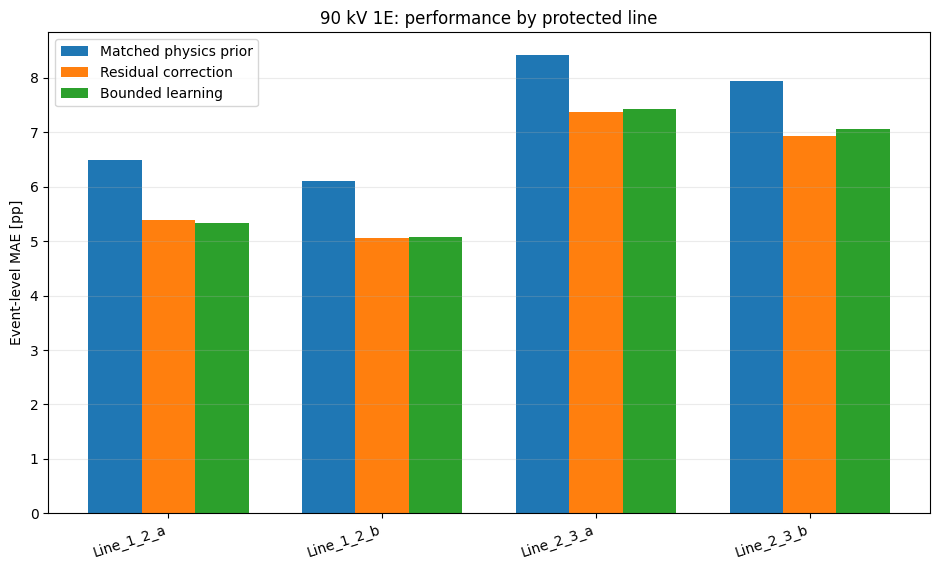

Saved: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/line_location_final/figures/linewise_prior_vs_model_mae_90kv_1e.svg


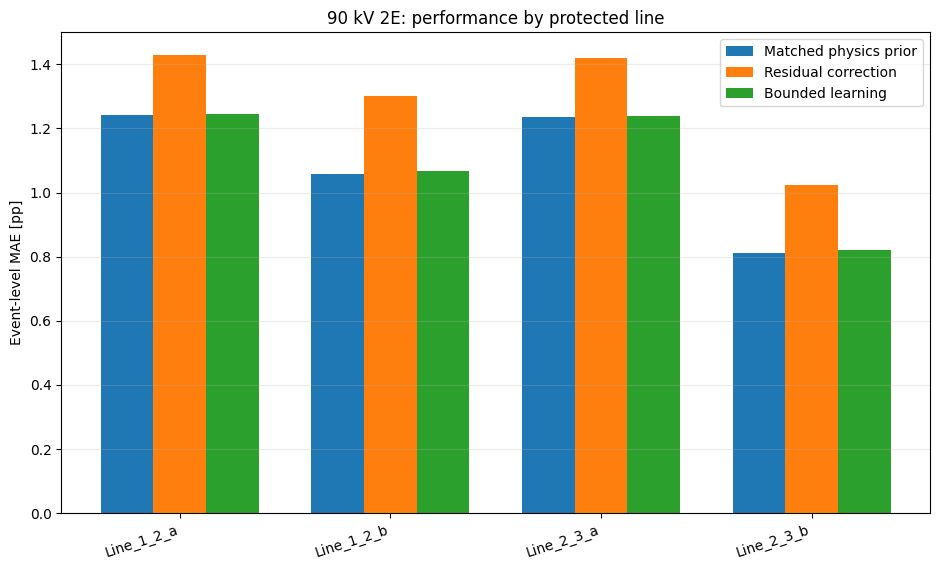

Saved: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/line_location_final/figures/linewise_prior_vs_model_mae_90kv_2e.svg


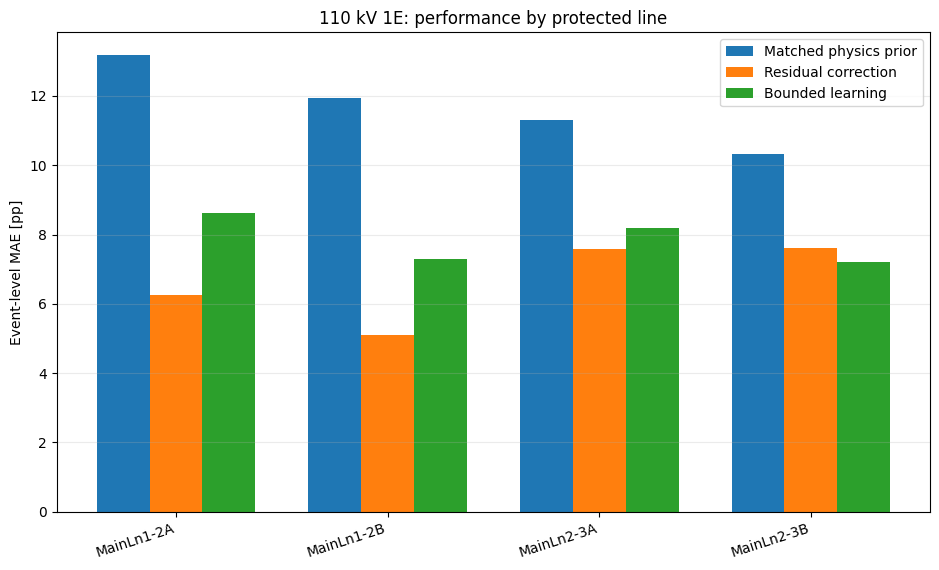

Saved: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/line_location_final/figures/linewise_prior_vs_model_mae_110kv_1e.svg


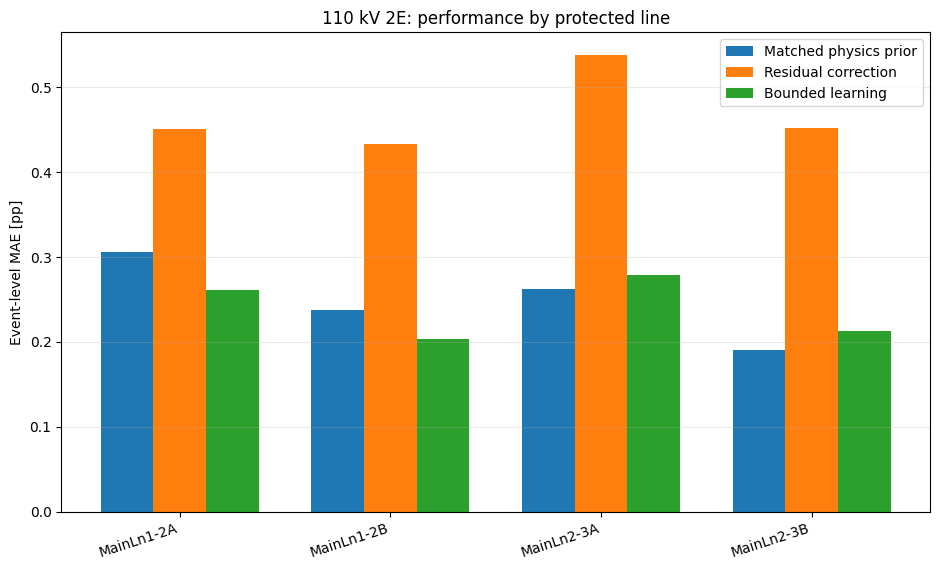

Saved: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/line_location_final/figures/linewise_prior_vs_model_mae_110kv_2e.svg


In [10]:
line_figure_paths = []


for voltage_kv in [
    90,
    110,
]:
    for prior_view in [
        "1E",
        "2E",
    ]:
        correction_id = (
            f"C{voltage_kv}-{prior_view}"
        )

        learning_id = (
            f"L{voltage_kv}-{prior_view}"
        )

        correction = linewise_metrics.loc[
            linewise_metrics[
                "experiment_id"
            ] == correction_id
        ].copy()

        learning = linewise_metrics.loc[
            linewise_metrics[
                "experiment_id"
            ] == learning_id
        ].copy()

        merged = correction[
            [
                "faulted_line",
                "prior_mae_pp",
                "model_mae_pp",
            ]
        ].merge(
            learning[
                [
                    "faulted_line",
                    "prior_mae_pp",
                    "model_mae_pp",
                ]
            ],
            on="faulted_line",
            how="inner",
            validate="one_to_one",
            suffixes=(
                "_correction",
                "_learning",
            ),
        )

        prior_difference = float(
            (
                merged[
                    "prior_mae_pp_correction"
                ]
                - merged[
                    "prior_mae_pp_learning"
                ]
            )
            .abs()
            .max()
        )

        if (
            prior_difference
            > PRIOR_ALIGNMENT_TOLERANCE_PP
        ):
            raise RuntimeError(
                "Matched line-level priors differ "
                f"for {voltage_kv} kV "
                f"{prior_view}."
            )

        order_map = {
            line_name: index
            for index, line_name
            in enumerate(
                LINE_ORDER[
                    voltage_kv
                ]
            )
        }

        merged["_line_order"] = (
            merged[
                "faulted_line"
            ].map(order_map)
        )

        merged = (
            merged
            .sort_values(
                "_line_order",
                kind="stable",
            )
            .drop(columns="_line_order")
        )

        positions = np.arange(
            len(merged)
        )

        width = 0.25

        plt.figure(
            figsize=(9.5, 5.8)
        )

        plt.bar(
            positions - width,
            merged[
                "prior_mae_pp_correction"
            ],
            width=width,
            label="Matched physics prior",
        )

        plt.bar(
            positions,
            merged[
                "model_mae_pp_correction"
            ],
            width=width,
            label="Residual correction",
        )

        plt.bar(
            positions + width,
            merged[
                "model_mae_pp_learning"
            ],
            width=width,
            label="Bounded learning",
        )

        plt.xticks(
            positions,
            merged[
                "faulted_line"
            ],
            rotation=18,
            ha="right",
        )

        plt.ylabel(
            "Event-level MAE [pp]"
        )

        plt.title(
            f"{voltage_kv} kV {prior_view}: "
            "performance by protected line"
        )

        plt.legend()

        plt.grid(
            axis="y",
            alpha=0.25,
        )

        plt.tight_layout()

        figure_path = (
            FIGURE_DIR
            / (
                "linewise_prior_vs_model_mae_"
                f"{voltage_kv}kv_"
                f"{prior_view.lower()}.svg"
            )
        )

        plt.savefig(
            figure_path,
            format="svg",
            bbox_inches="tight",
        )

        plt.show()

        line_figure_paths.append(
            figure_path
        )

        print("Saved:", figure_path)

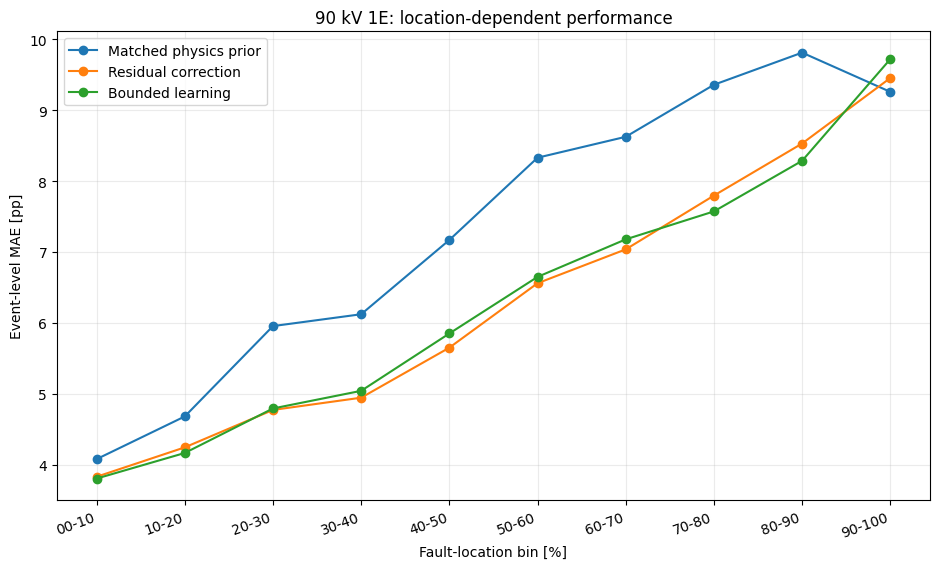

Saved: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/line_location_final/figures/location_dependent_mae_90kv_1e.svg


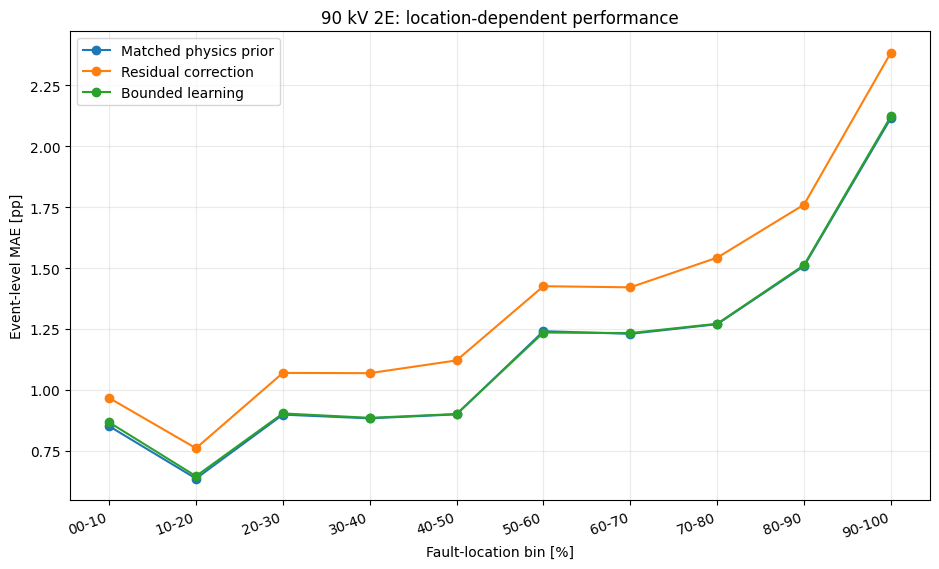

Saved: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/line_location_final/figures/location_dependent_mae_90kv_2e.svg


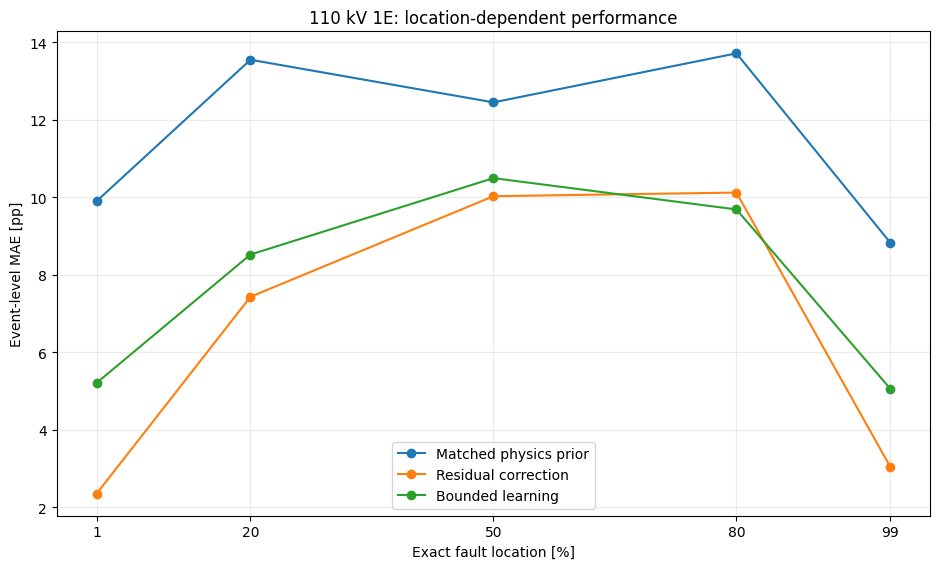

Saved: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/line_location_final/figures/location_dependent_mae_110kv_1e.svg


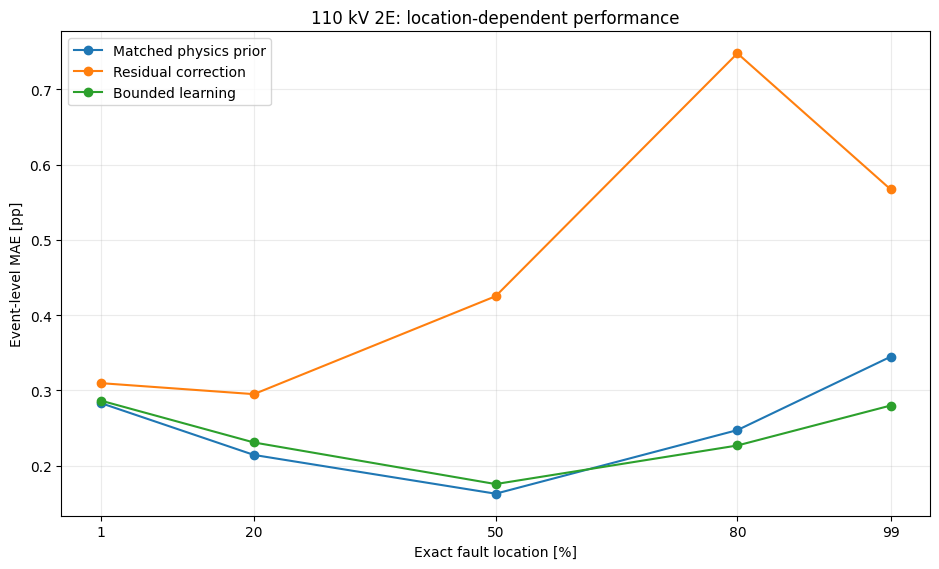

Saved: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/line_location_final/figures/location_dependent_mae_110kv_2e.svg


In [11]:
location_figure_paths = []


for voltage_kv in [
    90,
    110,
]:
    for prior_view in [
        "1E",
        "2E",
    ]:
        correction_id = (
            f"C{voltage_kv}-{prior_view}"
        )

        learning_id = (
            f"L{voltage_kv}-{prior_view}"
        )

        if voltage_kv == 110:
            source = (
                location_exact_110_metrics
            )

            location_column = (
                "fault_location_pct"
            )

            x_label = (
                "Exact fault location [%]"
            )

        else:
            source = (
                location_bin_metrics
            )

            location_column = (
                "location_bin_10pp"
            )

            x_label = (
                "Fault-location bin [%]"
            )

        correction = source.loc[
            source["experiment_id"]
            == correction_id
        ].copy()

        learning = source.loc[
            source["experiment_id"]
            == learning_id
        ].copy()

        merged = correction[
            [
                location_column,
                "prior_mae_pp",
                "model_mae_pp",
            ]
        ].merge(
            learning[
                [
                    location_column,
                    "prior_mae_pp",
                    "model_mae_pp",
                ]
            ],
            on=location_column,
            how="inner",
            validate="one_to_one",
            suffixes=(
                "_correction",
                "_learning",
            ),
        )

        prior_difference = float(
            (
                merged[
                    "prior_mae_pp_correction"
                ]
                - merged[
                    "prior_mae_pp_learning"
                ]
            )
            .abs()
            .max()
        )

        if (
            prior_difference
            > PRIOR_ALIGNMENT_TOLERANCE_PP
        ):
            raise RuntimeError(
                "Matched location-level priors "
                f"differ for {voltage_kv} kV "
                f"{prior_view}."
            )

        if voltage_kv == 110:
            merged = merged.sort_values(
                location_column,
                kind="stable",
            )

            x_values = merged[
                location_column
            ].to_numpy()

            tick_labels = [
                f"{value:g}"
                for value in x_values
            ]

        else:
            merged["_bin_order"] = (
                merged[
                    location_column
                ].map(
                    {
                        label: index
                        for index, label
                        in enumerate(
                            LOCATION_BIN_LABELS
                        )
                    }
                )
            )

            merged = (
                merged
                .sort_values(
                    "_bin_order",
                    kind="stable",
                )
                .drop(columns="_bin_order")
            )

            x_values = np.arange(
                len(merged)
            )

            tick_labels = merged[
                location_column
            ].tolist()

        plt.figure(
            figsize=(9.5, 5.8)
        )

        plt.plot(
            x_values,
            merged[
                "prior_mae_pp_correction"
            ],
            marker="o",
            label="Matched physics prior",
        )

        plt.plot(
            x_values,
            merged[
                "model_mae_pp_correction"
            ],
            marker="o",
            label="Residual correction",
        )

        plt.plot(
            x_values,
            merged[
                "model_mae_pp_learning"
            ],
            marker="o",
            label="Bounded learning",
        )

        plt.xticks(
            x_values,
            tick_labels,
            rotation=(
                20
                if voltage_kv == 90
                else 0
            ),
            ha=(
                "right"
                if voltage_kv == 90
                else "center"
            ),
        )

        plt.xlabel(x_label)

        plt.ylabel(
            "Event-level MAE [pp]"
        )

        plt.title(
            f"{voltage_kv} kV {prior_view}: "
            "location-dependent performance"
        )

        plt.legend()

        plt.grid(
            alpha=0.25,
        )

        plt.tight_layout()

        figure_path = (
            FIGURE_DIR
            / (
                "location_dependent_mae_"
                f"{voltage_kv}kv_"
                f"{prior_view.lower()}.svg"
            )
        )

        plt.savefig(
            figure_path,
            format="svg",
            bbox_inches="tight",
        )

        plt.show()

        location_figure_paths.append(
            figure_path
        )

        print("Saved:", figure_path)

In [12]:
if not MODEL_INPUT_110_PATH.exists():
    discovered_model_inputs = sorted(
        OUTPUT_ROOT.rglob(
            "*110kv*line_case_bestmae*"
            "model_input*.csv"
        )
    )

    if len(discovered_model_inputs) != 1:
        raise RuntimeError(
            "The final 110 kV one-ended "
            "model-input file could not be "
            "resolved uniquely.\n"
            + "\n".join(
                str(path)
                for path
                in discovered_model_inputs
            )
        )

    MODEL_INPUT_110_PATH = (
        discovered_model_inputs[0]
    )


candidate_paths: set[Path] = set()


# Chapter 4 exports.
for root in [
    OUTPUT_ROOT
    / "fresh_prior_exports",
    OUTPUT_ROOT
    / "model_inputs",
    OUTPUT_ROOT,
]:
    if not root.exists():
        continue

    for pattern in [
        "**/*110kv*.csv",
        "**/*110kv*.parquet",
        "**/*110kv*.pq",
    ]:
        for path in root.glob(
            pattern
        ):
            path_text = str(
                path
            ).lower()

            if any(
                excluded in path_text
                for excluded in [
                    "/preds/",
                    "metrics_by_",
                    "cv_metrics",
                    "subgroup",
                    "posthoc_unified",
                    "ablation_",
                    "line_location_final",
                ]
            ):
                continue

            candidate_paths.add(
                path
            )


# Relevant top-level vault exports, without recursively scanning the vault.
vault_root = Path(
    "/home/vault/iwi5/iwi5305h"
)

if vault_root.exists():
    for pattern in [
        "*110kv*prior*.csv",
        "*110kv*takagi*.csv",
        "*110kv*operator*.csv",
        "*110kv*linefixed*.csv",
        "*110kv*case*.csv",
    ]:
        candidate_paths.update(
            vault_root.glob(
                pattern
            )
        )


candidate_paths.add(
    MODEL_INPUT_110_PATH
)


inventory_rows = []


for path in sorted(
    candidate_paths
):
    try:
        if path.suffix.lower() == ".csv":
            header = pd.read_csv(
                path,
                nrows=0,
            )

        elif path.suffix.lower() in {
            ".parquet",
            ".pq",
        }:
            header = pd.read_parquet(
                path
            ).head(0)

        else:
            continue

    except Exception as error:
        inventory_rows.append(
            {
                "path": str(path),
                "readable": False,
                "error": repr(error),
            }
        )

        continue

    component_columns = {
        column: classify_component_column(
            column
        )
        for column in header.columns
    }

    component_columns = {
        column: kind
        for column, kind
        in component_columns.items()
        if kind is not None
    }

    sample_id_column = find_column(
        header,
        [
            "sample_id",
            "event_id",
        ],
    )

    window_column = find_column(
        header,
        [
            "window_idx",
            "window_index",
        ],
    )

    inventory_rows.append(
        {
            "path": str(path),
            "readable": True,
            "sample_id_column": (
                sample_id_column
            ),
            "window_column": (
                window_column
            ),
            "component_count": int(
                len(component_columns)
            ),
            "component_columns": json.dumps(
                component_columns,
                ensure_ascii=False,
            ),
            "all_columns": json.dumps(
                list(header.columns),
                ensure_ascii=False,
            ),
        }
    )


raw_prior_inventory = pd.DataFrame(
    inventory_rows
)


raw_prior_inventory.to_csv(
    AUDIT_DIR
    / "raw_prior_component_inventory.csv",
    index=False,
)


usable_inventory = raw_prior_inventory.loc[
    raw_prior_inventory[
        "readable"
    ].fillna(False)
    & raw_prior_inventory[
        "sample_id_column"
    ].notna()
    & (
        raw_prior_inventory[
            "component_count"
        ].fillna(0)
        > 0
    )
].copy()


print(
    "Candidate files inspected:",
    len(raw_prior_inventory),
)

print(
    "Files containing usable raw "
    "operator components:",
    len(usable_inventory),
)

display(
    usable_inventory[
        [
            "path",
            "sample_id_column",
            "window_column",
            "component_count",
            "component_columns",
        ]
    ]
)

Candidate files inspected: 28
Files containing usable raw operator components: 15


,path,sample_id_column,window_column,component_count,component_columns
0,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,sample_id,window_idx,32,"{""d_takagi_local_raw_pct"": ""local"", ""d_takagi_..."
6,/home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS...,sample_id,window_idx,32,"{""d_takagi_local_raw_pct"": ""local"", ""d_takagi_..."
14,/home/vault/iwi5/iwi5305h/kol_operator_feature...,sample_id,window_idx,32,"{""d_takagi_local_raw_pct"": ""local"", ""d_takagi_..."
15,/home/vault/iwi5/iwi5305h/kol_operator_feature...,sample_id,window_idx,32,"{""d_takagi_local_raw_pct"": ""local"", ""d_takagi_..."
16,/home/vault/iwi5/iwi5305h/kol_operator_feature...,sample_id,window_idx,32,"{""d_takagi_local_raw_pct"": ""local"", ""d_takagi_..."
17,/home/vault/iwi5/iwi5305h/kol_operator_feature...,sample_id,window_idx,16,"{""d_takagi_local_raw_pct"": ""local"", ""d_takagi_..."
19,/home/vault/iwi5/iwi5305h/kol_operator_feature...,sample_id,window_idx,28,"{""d_takagi_local_raw_pct"": ""local"", ""d_takagi_..."
20,/home/vault/iwi5/iwi5305h/kol_operator_feature...,sample_id,window_idx,29,"{""d_takagi_local_raw_pct"": ""local"", ""d_takagi_..."
21,/home/vault/iwi5/iwi5305h/kol_operator_feature...,sample_id,window_idx,29,"{""d_takagi_local_raw_pct"": ""local"", ""d_takagi_..."
22,/home/vault/iwi5/iwi5305h/kol_operator_feature...,sample_id,window_idx,16,"{""d_takagi_local_raw_pct"": ""local"", ""d_takagi_..."


In [13]:
model_input_110 = pd.read_csv(
    MODEL_INPUT_110_PATH
)


for required_column in [
    "sample_id",
    FINAL_PRIOR_COLUMN_110,
]:
    if required_column not in (
        model_input_110.columns
    ):
        raise KeyError(
            f"{required_column} missing from "
            f"{MODEL_INPUT_110_PATH}"
        )


if "window_idx" not in (
    model_input_110.columns
):
    raise KeyError(
        "The final 110 kV model input does "
        "not contain window_idx."
    )


model_input_110[
    "sample_id"
] = canonicalize_sample_ids(
    model_input_110["sample_id"]
)


window_110_reference = (
    window_data.loc[
        window_data["experiment_id"]
        == "C110-1E"
    ].copy()
)


window_110_reference[
    "sample_id"
] = canonicalize_sample_ids(
    window_110_reference[
        "sample_id"
    ]
)


required_window_columns = [
    "sample_id",
    "window_idx",
    "y_fault_line",
    "case",
    "y_true_pct",
    "y_prior_pct",
]

missing_window_columns = [
    column
    for column
    in required_window_columns
    if column
    not in window_110_reference.columns
]

if missing_window_columns:
    raise KeyError(
        "The unified window table is missing: "
        f"{missing_window_columns}"
    )


prior_base = (
    model_input_110[
        [
            "sample_id",
            "window_idx",
            FINAL_PRIOR_COLUMN_110,
        ]
    ]
    .merge(
        window_110_reference[
            required_window_columns
        ],
        on=[
            "sample_id",
            "window_idx",
        ],
        how="inner",
        validate="one_to_one",
    )
)


if len(prior_base) != 3648:
    raise RuntimeError(
        "The final model input did not align "
        "to all 3,648 110 kV windows.\n"
        f"Aligned rows: {len(prior_base)}"
    )


prior_base[
    "final_input_prior_pp"
] = pd.to_numeric(
    prior_base[
        FINAL_PRIOR_COLUMN_110
    ],
    errors="coerce",
)


model_input_vs_oof_difference = float(
    (
        prior_base[
            "final_input_prior_pp"
        ]
        - prior_base[
            "y_prior_pct"
        ]
    )
    .abs()
    .max()
)


if (
    model_input_vs_oof_difference
    > PRIOR_ALIGNMENT_TOLERANCE_PP
):
    raise RuntimeError(
        "The final model-input prior does not "
        "match the prior stored with the OOF "
        "predictions.\n"
        f"Maximum difference: "
        f"{model_input_vs_oof_difference}"
    )


print(
    "Final input-to-OOF prior maximum "
    "difference:",
    model_input_vs_oof_difference,
)

print(
    "Final model-input prior verified:",
    True,
)

display(
    prior_base[
        [
            "sample_id",
            "window_idx",
            "y_fault_line",
            "case",
            "y_true_pct",
            "final_input_prior_pp",
            "y_prior_pct",
        ]
    ].head()
)

Final input-to-OOF prior maximum difference: 5.965728760770617e-06
Final model-input prior verified: True


,sample_id,window_idx,y_fault_line,case,y_true_pct,final_input_prior_pp,y_prior_pct
0,0,8,MainLn1-2A,slg_a,1.0,0.000000,0.000000
1,0,9,MainLn1-2A,slg_a,1.0,0.000000,0.000000
2,0,10,MainLn1-2A,slg_a,1.0,0.000000,0.000000
3,0,11,MainLn1-2A,slg_a,1.0,0.000000,0.000000
4,1,8,MainLn1-2A,slg_a,20.0,14.672338,14.672337


In [14]:
# ---------------------------------------------------------------------
# Align all discovered raw operator components to the final 110 kV
# model-input cohort.
# ---------------------------------------------------------------------

component_series_records = []


for _, inventory_row in (
    usable_inventory.iterrows()
):
    path = Path(
        inventory_row["path"]
    )

    component_mapping = json.loads(
        inventory_row[
            "component_columns"
        ]
    )

    try:
        if path.suffix.lower() == ".csv":
            candidate_frame = pd.read_csv(
                path
            )
        else:
            candidate_frame = (
                pd.read_parquet(path)
            )

    except Exception as error:
        warnings.warn(
            f"Could not load {path}: "
            f"{error!r}"
        )

        continue

    sample_column = (
        inventory_row[
            "sample_id_column"
        ]
    )

    window_column = (
        inventory_row[
            "window_column"
        ]
    )

    candidate_frame[
        sample_column
    ] = canonicalize_sample_ids(
        candidate_frame[
            sample_column
        ]
    )

    key_columns = [
        sample_column,
    ]

    if (
        isinstance(
            window_column,
            str,
        )
        and window_column
        in candidate_frame.columns
    ):
        key_columns.append(
            window_column
        )

    selected_columns = list(
        dict.fromkeys(
            key_columns
            + list(
                component_mapping.keys()
            )
        )
    )

    candidate_frame = (
        candidate_frame[
            selected_columns
        ].copy()
    )

    rename_map = {
        sample_column: "sample_id",
    }

    if len(key_columns) == 2:
        rename_map[
            window_column
        ] = "window_idx"

    candidate_frame = (
        candidate_frame.rename(
            columns=rename_map
        )
    )

    merge_keys = [
        "sample_id",
    ]

    if "window_idx" in (
        candidate_frame.columns
    ):
        merge_keys.append(
            "window_idx"
        )

    duplicate_keys = (
        candidate_frame.duplicated(
            subset=merge_keys,
            keep=False,
        )
    )

    if duplicate_keys.any():
        duplicate_group = (
            candidate_frame.loc[
                duplicate_keys
            ]
            .groupby(
                merge_keys,
                dropna=False,
            )
        )

        inconsistent = False

        for component_column in (
            component_mapping
        ):
            spreads = duplicate_group[
                component_column
            ].agg(
                lambda values: (
                    pd.to_numeric(
                        values,
                        errors="coerce",
                    ).max()
                    - pd.to_numeric(
                        values,
                        errors="coerce",
                    ).min()
                )
            )

            maximum_spread = (
                pd.to_numeric(
                    spreads,
                    errors="coerce",
                )
                .fillna(0.0)
                .abs()
                .max()
            )

            if (
                maximum_spread
                > PRIOR_ALIGNMENT_TOLERANCE_PP
            ):
                inconsistent = True
                break

        if inconsistent:
            warnings.warn(
                "Skipping candidate with "
                "inconsistent duplicate keys: "
                f"{path}"
            )

            continue

        candidate_frame = (
            candidate_frame
            .groupby(
                merge_keys,
                as_index=False,
                dropna=False,
            )
            .first()
        )

    for (
        component_column,
        component_kind,
    ) in component_mapping.items():
        component_data = (
            candidate_frame[
                merge_keys
                + [
                    component_column,
                ]
            ].copy()
        )

        merged_component = (
            prior_base.merge(
                component_data,
                on=merge_keys,
                how="left",
                validate=(
                    "one_to_one"
                    if "window_idx"
                    in merge_keys
                    else "many_to_one"
                ),
            )
        )

        (
            candidate_percent,
            scale_rule,
        ) = scale_candidate_to_percent(
            merged_component[
                component_column
            ],
            merged_component[
                "final_input_prior_pp"
            ],
        )

        component_series_records.append(
            {
                "source_file": str(
                    path
                ),
                "component_column": (
                    component_column
                ),
                "component_kind": (
                    component_kind
                ),
                "scale_rule": scale_rule,
                "merge_keys": ",".join(
                    merge_keys
                ),
                "coverage_rows": int(
                    candidate_percent
                    .notna()
                    .sum()
                ),
                "values": (
                    candidate_percent
                    .reset_index(drop=True)
                ),
            }
        )


if not component_series_records:
    raise RuntimeError(
        "No raw 110 kV prior components could "
        "be aligned to the final model-input "
        "cohort."
    )


# ---------------------------------------------------------------------
# Define which rule is mandatory and which is diagnostic.
# ---------------------------------------------------------------------

def expected_component_for_group(
    line_name: str,
    case_name: str,
) -> tuple[str, str]:
    line_name = str(
        line_name
    ).strip()

    case_name = (
        str(case_name)
        .strip()
        .lower()
    )

    if case_name in LINE_TERMINAL_CASES:
        if line_name not in (
            EXPECTED_LINE_TERMINAL
        ):
            raise KeyError(
                "No terminal convention is "
                f"registered for line "
                f"{line_name!r}."
            )

        return (
            EXPECTED_LINE_TERMINAL[
                line_name
            ],
            "REQUIRED_TERMINAL_CONVENTION",
        )

    if case_name in SLG_CASES:
        return (
            SLG_COMPONENT_HYPOTHESES[
                case_name
            ],
            "DIAGNOSTIC_SLG_PROVENANCE",
        )

    raise KeyError(
        "No prior-rule audit scope is "
        f"registered for case "
        f"{case_name!r} on line "
        f"{line_name!r}."
    )


def acceptable_component_kinds(
    expected_kind: str,
) -> set[str]:
    if expected_kind == (
        "remote_direction_corrected"
    ):
        return {
            "remote_flipped",
            "remote_raw",
        }

    return {
        expected_kind,
    }


# ---------------------------------------------------------------------
# Evaluate every line/case group.
# ---------------------------------------------------------------------

group_audit_rows = []


for (
    line_name,
    case_name,
), group in prior_base.groupby(
    [
        "y_fault_line",
        "case",
    ],
    sort=True,
    observed=False,
):
    group_index = (
        group.index.to_numpy()
    )

    (
        expected_kind,
        audit_scope,
    ) = expected_component_for_group(
        str(line_name),
        str(case_name),
    )

    required_for_terminal_audit = bool(
        audit_scope
        == "REQUIRED_TERMINAL_CONVENTION"
    )

    acceptable_kinds = (
        acceptable_component_kinds(
            expected_kind
        )
    )

    candidate_scores = []

    for record in (
        component_series_records
    ):
        if (
            record["component_kind"]
            not in acceptable_kinds
        ):
            continue

        candidate_values = (
            record["values"].iloc[
                group_index
            ]
            .reset_index(drop=True)
        )

        final_values = (
            prior_base.loc[
                group_index,
                "final_input_prior_pp",
            ]
            .reset_index(drop=True)
        )

        for transform in (
            possible_transforms(
                record[
                    "component_kind"
                ]
            )
        ):
            transformed = (
                apply_transform(
                    candidate_values,
                    transform,
                )
            )

            valid = (
                np.isfinite(
                    transformed
                )
                & np.isfinite(
                    final_values
                )
            )

            coverage = int(
                valid.sum()
            )

            if coverage == 0:
                continue

            differences = (
                transformed[valid]
                - final_values[valid]
            ).abs()

            exact_rate = float(
                np.mean(
                    differences
                    <= PRIOR_ALIGNMENT_TOLERANCE_PP
                )
            )

            candidate_scores.append(
                {
                    "source_file": record[
                        "source_file"
                    ],
                    "component_column": (
                        record[
                            "component_column"
                        ]
                    ),
                    "component_kind": (
                        record[
                            "component_kind"
                        ]
                    ),
                    "scale_rule": record[
                        "scale_rule"
                    ],
                    "transform": transform,
                    "coverage": coverage,
                    "coverage_rate": float(
                        coverage
                        / len(group)
                    ),
                    "mean_abs_difference_pp": float(
                        differences.mean()
                    ),
                    "max_abs_difference_pp": float(
                        differences.max()
                    ),
                    "exact_match_rate": (
                        exact_rate
                    ),
                }
            )

    # -------------------------------------------------------------
    # No recoverable raw candidate
    # -------------------------------------------------------------

    if not candidate_scores:
        group_audit_rows.append(
            {
                "faulted_line": (
                    line_name
                ),
                "case": case_name,
                "support_windows": int(
                    len(group)
                ),
                "audit_scope": (
                    audit_scope
                ),
                "required_for_terminal_audit": (
                    required_for_terminal_audit
                ),
                "expected_component": (
                    expected_kind
                ),
                "matched_component_kind": (
                    pd.NA
                ),
                "matched_component_column": (
                    pd.NA
                ),
                "applied_transform": (
                    pd.NA
                ),
                "scale_rule": pd.NA,
                "coverage_rate": np.nan,
                "exact_match_rate": np.nan,
                "mean_abs_difference_pp": (
                    np.nan
                ),
                "max_abs_difference_pp": (
                    np.nan
                ),
                "source_file": pd.NA,
                "component_match_verified": (
                    False
                ),
                "terminal_requirement_passed": (
                    not required_for_terminal_audit
                ),
                "provenance_status": (
                    "UNRESOLVED_COMPONENT_PROVENANCE"
                ),
                "failure_reason": (
                    "The final prepared prior is "
                    "available and verified against "
                    "the OOF prior, but the raw "
                    "component column was not "
                    "recoverable from the "
                    "discovered artifacts."
                ),
            }
        )

        continue

    # -------------------------------------------------------------
    # Select the best available raw component match.
    # -------------------------------------------------------------

    score_frame = pd.DataFrame(
        candidate_scores
    )

    best = (
        score_frame
        .sort_values(
            [
                "coverage_rate",
                "exact_match_rate",
                "max_abs_difference_pp",
                "mean_abs_difference_pp",
            ],
            ascending=[
                False,
                False,
                True,
                True,
            ],
            kind="stable",
        )
        .iloc[0]
    )

    component_match_verified = bool(
        best["coverage_rate"]
        >= MIN_EXACT_MATCH_RATE
        and best[
            "exact_match_rate"
        ] >= MIN_EXACT_MATCH_RATE
        and best[
            "max_abs_difference_pp"
        ]
        <= PRIOR_ALIGNMENT_TOLERANCE_PP
    )

    terminal_requirement_passed = bool(
        component_match_verified
        if required_for_terminal_audit
        else True
    )

    if component_match_verified:
        provenance_status = (
            "NUMERICALLY_VERIFIED"
        )

    elif required_for_terminal_audit:
        provenance_status = (
            "TERMINAL_CONVENTION_FAILED"
        )

    else:
        provenance_status = (
            "SLG_COMPONENT_NOT_RECOVERABLE"
        )

    group_audit_rows.append(
        {
            "faulted_line": (
                line_name
            ),
            "case": case_name,
            "support_windows": int(
                len(group)
            ),
            "audit_scope": (
                audit_scope
            ),
            "required_for_terminal_audit": (
                required_for_terminal_audit
            ),
            "expected_component": (
                expected_kind
            ),
            "matched_component_kind": (
                best[
                    "component_kind"
                ]
            ),
            "matched_component_column": (
                best[
                    "component_column"
                ]
            ),
            "applied_transform": (
                best["transform"]
            ),
            "scale_rule": (
                best["scale_rule"]
            ),
            "coverage_rate": (
                best[
                    "coverage_rate"
                ]
            ),
            "exact_match_rate": (
                best[
                    "exact_match_rate"
                ]
            ),
            "mean_abs_difference_pp": (
                best[
                    "mean_abs_difference_pp"
                ]
            ),
            "max_abs_difference_pp": (
                best[
                    "max_abs_difference_pp"
                ]
            ),
            "source_file": (
                best["source_file"]
            ),
            "component_match_verified": (
                component_match_verified
            ),
            "terminal_requirement_passed": (
                terminal_requirement_passed
            ),
            "provenance_status": (
                provenance_status
            ),
            "failure_reason": (
                ""
                if component_match_verified
                else (
                    "The best discovered component "
                    "does not reproduce the final "
                    "prepared prior. This is fatal "
                    "only for rows in the required "
                    "fixed terminal-convention "
                    "audit."
                )
            ),
        }
    )


prior_case_rule_audit = pd.DataFrame(
    group_audit_rows
)


prior_case_rule_audit.to_csv(
    AUDIT_DIR
    / "oneended_prior_case_rule_audit.csv",
    index=False,
)


# ---------------------------------------------------------------------
# Separate mandatory terminal verification from optional SLG provenance.
# ---------------------------------------------------------------------

required_terminal_rows = (
    prior_case_rule_audit.loc[
        prior_case_rule_audit[
            "required_for_terminal_audit"
        ].fillna(False)
    ].copy()
)


failed_terminal_rows = (
    required_terminal_rows.loc[
        ~required_terminal_rows[
            "terminal_requirement_passed"
        ].fillna(False)
    ].copy()
)


slg_provenance_rows = (
    prior_case_rule_audit.loc[
        prior_case_rule_audit[
            "audit_scope"
        ]
        == "DIAGNOSTIC_SLG_PROVENANCE"
    ].copy()
)


unresolved_slg_rows = (
    slg_provenance_rows.loc[
        ~slg_provenance_rows[
            "component_match_verified"
        ].fillna(False)
    ].copy()
)


print("=" * 120)
print("ONE-ENDED PRIOR-SELECTION AUDIT")
print("=" * 120)


print(
    "Required terminal-convention groups:",
    len(required_terminal_rows),
)

print(
    "Required terminal groups verified:",
    int(
        required_terminal_rows[
            "terminal_requirement_passed"
        ].fillna(False).sum()
    ),
    "/",
    len(required_terminal_rows),
)


print(
    "SLG provenance groups:",
    len(slg_provenance_rows),
)

print(
    "SLG component groups numerically reconstructed:",
    int(
        slg_provenance_rows[
            "component_match_verified"
        ].fillna(False).sum()
    ),
    "/",
    len(slg_provenance_rows),
)


if not failed_terminal_rows.empty:
    print(
        "\nFAILED REQUIRED TERMINAL GROUPS"
    )

    display(
        failed_terminal_rows[
            [
                "faulted_line",
                "case",
                "expected_component",
                "matched_component_kind",
                "matched_component_column",
                "applied_transform",
                "coverage_rate",
                "exact_match_rate",
                "max_abs_difference_pp",
                "provenance_status",
                "source_file",
            ]
        ]
    )


if not unresolved_slg_rows.empty:
    print(
        "\nUNRESOLVED SLG COMPONENT PROVENANCE"
    )

    display(
        unresolved_slg_rows[
            [
                "faulted_line",
                "case",
                "expected_component",
                "matched_component_kind",
                "matched_component_column",
                "coverage_rate",
                "exact_match_rate",
                "max_abs_difference_pp",
                "provenance_status",
            ]
        ]
    )

    print(
        "\nThese unresolved SLG component rows "
        "do not invalidate the fixed line-"
        "dependent terminal convention."
    )

    print(
        "The final prepared model-input prior "
        "was already verified against the OOF "
        "prior in Cell 12."
    )


terminal_component_audit_verified = bool(
    failed_terminal_rows.empty
)


slg_component_provenance_complete = bool(
    unresolved_slg_rows.empty
)


if (
    STRICT_TERMINAL_AUDIT
    and not terminal_component_audit_verified
):
    raise RuntimeError(
        "The required fixed line-dependent "
        "terminal convention could not be "
        "verified for all 3ph, LL, and LLG "
        "line/case groups.\n"
        "Inspect:\n"
        + str(
            AUDIT_DIR
            / "oneended_prior_case_rule_audit.csv"
        )
    )


print(
    "\nFixed terminal convention verified:",
    terminal_component_audit_verified,
)

print(
    "SLG component provenance complete:",
    slg_component_provenance_complete,
)

ONE-ENDED PRIOR-SELECTION AUDIT
Required terminal-convention groups: 28
Required terminal groups verified: 28 / 28
SLG provenance groups: 12
SLG component groups numerically reconstructed: 4 / 12

UNRESOLVED SLG COMPONENT PROVENANCE


,faulted_line,case,expected_component,matched_component_kind,matched_component_column,coverage_rate,exact_match_rate,max_abs_difference_pp,provenance_status
7,MainLn1-2A,slg_a,old,<NA>,<NA>,NaN,NaN,NaN,UNRESOLVED_COMPONENT_PROVENANCE
8,MainLn1-2A,slg_b,both_mean,both_mean,d_mod_takagi_tf_only_p_both_mean_pct,1.0,0.129032,63.440090,SLG_COMPONENT_NOT_RECOVERABLE
17,MainLn1-2B,slg_a,old,<NA>,<NA>,NaN,NaN,NaN,UNRESOLVED_COMPONENT_PROVENANCE
18,MainLn1-2B,slg_b,both_mean,both_mean,d_mod_takagi_tf_only_p_both_mean_pct,1.0,0.161290,77.120368,SLG_COMPONENT_NOT_RECOVERABLE
27,MainLn2-3A,slg_a,old,<NA>,<NA>,NaN,NaN,NaN,UNRESOLVED_COMPONENT_PROVENANCE
28,MainLn2-3A,slg_b,both_mean,both_mean,d_mod_takagi_tf_only_p_both_mean_pct,1.0,0.129032,68.023859,SLG_COMPONENT_NOT_RECOVERABLE
37,MainLn2-3B,slg_a,old,<NA>,<NA>,NaN,NaN,NaN,UNRESOLVED_COMPONENT_PROVENANCE
38,MainLn2-3B,slg_b,both_mean,both_mean,d_mod_takagi_tf_only_p_both_mean_pct,1.0,0.161290,78.928028,SLG_COMPONENT_NOT_RECOVERABLE



These unresolved SLG component rows do not invalidate the fixed line-dependent terminal convention.
The final prepared model-input prior was already verified against the OOF prior in Cell 12.

Fixed terminal convention verified: True
SLG component provenance complete: False


In [15]:
# ---------------------------------------------------------------------
# Required fixed terminal-convention rows
# ---------------------------------------------------------------------

line_terminal_audit = (
    prior_case_rule_audit.loc[
        prior_case_rule_audit[
            "required_for_terminal_audit"
        ].fillna(False)
    ].copy()
)


terminal_summary_rows = []


for line_name in (
    LINE_ORDER[110]
):
    line_audit = (
        line_terminal_audit.loc[
            line_terminal_audit[
                "faulted_line"
            ] == line_name
        ].copy()
    )

    expected_terminal = (
        EXPECTED_LINE_TERMINAL[
            line_name
        ]
    )

    observed_cases = set(
        line_audit[
            "case"
        ]
        .astype(str)
        .str.strip()
        .str.lower()
        .tolist()
    )

    complete_case_set = bool(
        observed_cases
        == LINE_TERMINAL_CASES
    )

    all_verified = bool(
        not line_audit.empty
        and complete_case_set
        and line_audit[
            "terminal_requirement_passed"
        ].fillna(False).all()
    )

    matched_kinds = sorted(
        line_audit[
            "matched_component_kind"
        ]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    transforms = sorted(
        line_audit[
            "applied_transform"
        ]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    source_files = sorted(
        line_audit[
            "source_file"
        ]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    if expected_terminal == "local":
        terminal_source = (
            "local terminal"
        )

        direction_conversion = (
            "none"
        )

    else:
        terminal_source = (
            "remote terminal"
        )

        if any(
            str(transform).startswith(
                "hundred_minus"
            )
            for transform in transforms
        ):
            direction_conversion = (
                "100 - remote-terminal distance"
            )

        elif "remote_flipped" in (
            matched_kinds
        ):
            direction_conversion = (
                "already direction-corrected "
                "remote estimate"
            )

        else:
            direction_conversion = (
                "unresolved"
            )

    terminal_summary_rows.append(
        {
            "faulted_line": (
                line_name
            ),
            "expected_terminal_convention": (
                expected_terminal
            ),
            "verified_terminal_source": (
                terminal_source
            ),
            "direction_conversion": (
                direction_conversion
            ),
            "expected_case_count": int(
                len(
                    LINE_TERMINAL_CASES
                )
            ),
            "observed_case_count": int(
                len(observed_cases)
            ),
            "complete_case_set": (
                complete_case_set
            ),
            "verified_line_terminal_cases": (
                ",".join(
                    sorted(
                        observed_cases
                    )
                )
            ),
            "matched_component_kinds": (
                ",".join(
                    matched_kinds
                )
            ),
            "applied_transforms": (
                ",".join(
                    transforms
                )
            ),
            "final_model_input_column": (
                FINAL_PRIOR_COLUMN_110
            ),
            "model_input_file": str(
                MODEL_INPUT_110_PATH
            ),
            "raw_component_sources": (
                " | ".join(
                    source_files
                )
            ),
            "verified": (
                all_verified
            ),
        }
    )


terminal_convention_audit = (
    pd.DataFrame(
        terminal_summary_rows
    )
)


terminal_convention_audit.to_csv(
    TABLE_DIR
    / "oneended_terminal_convention_audit.csv",
    index=False,
)


write_latex_table(
    terminal_convention_audit[
        [
            "faulted_line",
            "verified_terminal_source",
            "direction_conversion",
            "verified_line_terminal_cases",
            "verified",
        ]
    ],
    LATEX_DIR
    / "oneended_terminal_convention_audit.tex",
)


# ---------------------------------------------------------------------
# SLG component provenance — diagnostic only
# ---------------------------------------------------------------------

slg_provenance_audit = (
    prior_case_rule_audit.loc[
        prior_case_rule_audit[
            "audit_scope"
        ]
        == "DIAGNOSTIC_SLG_PROVENANCE"
    ].copy()
)


slg_provenance_audit.to_csv(
    TABLE_DIR
    / "oneended_slg_component_provenance.csv",
    index=False,
)


terminal_verified = bool(
    terminal_component_audit_verified
    and terminal_convention_audit[
        "verified"
    ].fillna(False).all()
)


if (
    STRICT_TERMINAL_AUDIT
    and not terminal_verified
):
    raise RuntimeError(
        "The fixed line-dependent terminal "
        "convention was not verified for all "
        "four protected lines."
    )


print("=" * 120)
print("VERIFIED FIXED TERMINAL CONVENTION")
print("=" * 120)

display(
    terminal_convention_audit[
        [
            "faulted_line",
            "expected_terminal_convention",
            "verified_terminal_source",
            "direction_conversion",
            "verified_line_terminal_cases",
            "matched_component_kinds",
            "applied_transforms",
            "verified",
        ]
    ]
)


print(
    "\nSLG COMPONENT-PROVENANCE STATUS"
)

display(
    slg_provenance_audit[
        [
            "faulted_line",
            "case",
            "expected_component",
            "matched_component_kind",
            "matched_component_column",
            "exact_match_rate",
            "component_match_verified",
            "provenance_status",
        ]
    ]
)


print(
    "\nFixed terminal convention verified:",
    terminal_verified,
)

print(
    "SLG component provenance complete:",
    slg_component_provenance_complete,
)

VERIFIED FIXED TERMINAL CONVENTION


,faulted_line,expected_terminal_convention,verified_terminal_source,direction_conversion,verified_line_terminal_cases,matched_component_kinds,applied_transforms,verified
0,MainLn1-2A,local,local terminal,none,"3ph,ll_ab,ll_bc,ll_ca,llg_ab,llg_bc,llg_ca",local,identity,True
1,MainLn1-2B,local,local terminal,none,"3ph,ll_ab,ll_bc,ll_ca,llg_ab,llg_bc,llg_ca",local,identity,True
2,MainLn2-3A,remote_direction_corrected,remote terminal,100 - remote-terminal distance,"3ph,ll_ab,ll_bc,ll_ca,llg_ab,llg_bc,llg_ca","remote_flipped,remote_raw","hundred_minus,identity",True
3,MainLn2-3B,remote_direction_corrected,remote terminal,100 - remote-terminal distance,"3ph,ll_ab,ll_bc,ll_ca,llg_ab,llg_bc,llg_ca","remote_flipped,remote_raw","hundred_minus,identity",True



SLG COMPONENT-PROVENANCE STATUS


,faulted_line,case,expected_component,matched_component_kind,matched_component_column,exact_match_rate,component_match_verified,provenance_status
7,MainLn1-2A,slg_a,old,<NA>,<NA>,NaN,False,UNRESOLVED_COMPONENT_PROVENANCE
8,MainLn1-2A,slg_b,both_mean,both_mean,d_mod_takagi_tf_only_p_both_mean_pct,0.129032,False,SLG_COMPONENT_NOT_RECOVERABLE
9,MainLn1-2A,slg_c,both_mean,both_mean,d_both_mean_abs_pct,1.000000,True,NUMERICALLY_VERIFIED
17,MainLn1-2B,slg_a,old,<NA>,<NA>,NaN,False,UNRESOLVED_COMPONENT_PROVENANCE
18,MainLn1-2B,slg_b,both_mean,both_mean,d_mod_takagi_tf_only_p_both_mean_pct,0.161290,False,SLG_COMPONENT_NOT_RECOVERABLE
19,MainLn1-2B,slg_c,both_mean,both_mean,d_both_mean_abs_pct,1.000000,True,NUMERICALLY_VERIFIED
27,MainLn2-3A,slg_a,old,<NA>,<NA>,NaN,False,UNRESOLVED_COMPONENT_PROVENANCE
28,MainLn2-3A,slg_b,both_mean,both_mean,d_mod_takagi_tf_only_p_both_mean_pct,0.129032,False,SLG_COMPONENT_NOT_RECOVERABLE
29,MainLn2-3A,slg_c,both_mean,both_mean,d_both_mean_abs_pct,1.000000,True,NUMERICALLY_VERIFIED
37,MainLn2-3B,slg_a,old,<NA>,<NA>,NaN,False,UNRESOLVED_COMPONENT_PROVENANCE



Fixed terminal convention verified: True
SLG component provenance complete: False


In [16]:
def json_safe_records(
    frame: pd.DataFrame,
) -> list[dict[str, Any]]:
    clean = frame.copy()

    clean = clean.astype(
        object
    ).where(
        pd.notna(clean),
        None,
    )

    for column in clean.columns:
        clean[column] = clean[
            column
        ].map(
            lambda value: (
                value.item()
                if isinstance(
                    value,
                    np.generic,
                )
                else value
            )
        )

    return clean.to_dict(
        orient="records"
    )


terminal_audit_payload = {
    "status": (
        "PASS"
        if terminal_verified
        else "FAIL"
    ),

    "audit_type": (
        "numerical_match_between_final_"
        "model_input_prior_and_raw_"
        "physical_operator_components"
    ),

    "final_model_input_file": str(
        MODEL_INPUT_110_PATH
    ),

    "final_model_input_column": (
        FINAL_PRIOR_COLUMN_110
    ),

    "oof_reference_experiment": (
        "C110-1E"
    ),

    "oof_prior_max_difference_pp": float(
        model_input_vs_oof_difference
    ),

    "alignment_tolerance_pp": float(
        PRIOR_ALIGNMENT_TOLERANCE_PP
    ),

    "fixed_terminal_scope": (
        sorted(
            LINE_TERMINAL_CASES
        )
    ),

    "slg_diagnostic_scope": (
        sorted(
            SLG_CASES
        )
    ),

    "fixed_terminal_convention_verified": (
        bool(
            terminal_verified
        )
    ),

    "slg_component_provenance_complete": (
        bool(
            slg_component_provenance_complete
        )
    ),

    "line_conventions": (
        json_safe_records(
            terminal_convention_audit
        )
    ),

    "all_line_case_audit_rows": (
        json_safe_records(
            prior_case_rule_audit
        )
    ),

    "slg_provenance_rows": (
        json_safe_records(
            slg_provenance_audit
        )
    ),

    "interpretation": {
        "fixed_terminal_rule": (
            "The fixed line-dependent terminal "
            "convention was tested for 3ph, LL, "
            "and LLG cases."
        ),

        "slg_scope": (
            "SLG cases use separate case-aware "
            "prior rules. Missing raw SLG "
            "component provenance does not "
            "invalidate the fixed terminal rule."
        ),

        "prepared_prior_verification": (
            "The final model-input prior column "
            "was independently verified against "
            "the prior stored in the final OOF "
            "prediction table."
        ),

        "inference_constraint": (
            "The neural models receive the "
            "prepared physical prior as an "
            "input. They do not select the "
            "terminal using the true fault "
            "location at inference."
        ),
    },

    "creation_timestamp_utc": (
        datetime.now(
            timezone.utc
        ).isoformat()
    ),
}


terminal_json_path = (
    FINAL_DIR
    / "terminal_convention_audit.json"
)


with terminal_json_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        terminal_audit_payload,
        file,
        indent=2,
        ensure_ascii=False,
    )


print("Saved:", terminal_json_path)

Saved: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/line_location_final/terminal_convention_audit.json


In [18]:
writing_record_path = (
    FINAL_DIR
    / "line_location_writing_record.md"
)


def markdown_table(
    frame: pd.DataFrame,
    columns: list[str],
) -> str:
    selected = frame[
        columns
    ].copy()

    for column in selected.columns:
        if pd.api.types.is_numeric_dtype(
            selected[column]
        ):
            selected[column] = (
                selected[column]
                .map(
                    lambda value: (
                        ""
                        if pd.isna(value)
                        else f"{value:.3f}"
                    )
                )
            )

    return selected.to_markdown(
        index=False
    )


writing_lines = [
    "# Chapter 4 Line-Wise and "
    "Location-Dependent Analysis",

    "",

    "## Analysis status",

    "",

    "- Existing final experiments reused: 8",
    "- New training runs launched: 0",
    "- Primary analysis unit: physical event",
    "- Line-wise tables complete: yes",
    "- Fixed location-bin tables complete: yes",
    "- Exact 110 kV location table complete: yes",

    (
        "- Fixed terminal convention verified: "
        f"{str(terminal_verified).lower()}"
    ),

    (
        "- SLG raw-component provenance complete: "
        f"{str(slg_component_provenance_complete).lower()}"
    ),

    "",

    "The incomplete SLG raw-component provenance "
    "does not invalidate the final prepared prior. "
    "The prepared prior was verified directly "
    "against the final out-of-fold prediction table.",

    "",

    "## Actual 110 kV fault locations",

    "",

    ", ".join(
        f"{value:g}%"
        for value in exact_locations_110
    ),

    "",

    "## Line-wise event metrics",

    "",

    markdown_table(
        linewise_metrics,
        [
            "experiment_id",
            "faulted_line",
            "support",
            "prior_mae_pp",
            "model_mae_pp",
            "mae_reduction_pp",
            "model_p95_ae_pp",
            "improved_rate_pct",
            "worsened_rate_pct",
        ],
    ),

    "",

    "## Exact 110 kV location metrics",

    "",

    markdown_table(
        location_exact_110_metrics,
        [
            "experiment_id",
            "fault_location_pct",
            "support",
            "prior_mae_pp",
            "model_mae_pp",
            "mae_reduction_pp",
            "model_p95_ae_pp",
        ],
    ),

    "",

    "## Verified fixed one-ended terminal convention",

    "",

    markdown_table(
        terminal_convention_audit,
        [
            "faulted_line",
            "verified_terminal_source",
            "direction_conversion",
            "verified_line_terminal_cases",
            "verified",
        ],
    ),

    "",

    "## SLG component-provenance status",

    "",

    markdown_table(
        slg_provenance_audit,
        [
            "faulted_line",
            "case",
            "expected_component",
            "matched_component_kind",
            "exact_match_rate",
            "component_match_verified",
            "provenance_status",
        ],
    ),

    "",

    "## Interpretation rules",

    "",

    (
        "The line-wise and location-dependent "
        "metrics are calculated from final "
        "out-of-fold event predictions."
    ),

    "",

    (
        "The 110 kV location trend is reported "
        "at the actual target values in the "
        "dataset. Fixed 10-percentage-point "
        "bins are retained for cross-topology "
        "comparison."
    ),

    "",

    (
        "The fixed line-dependent local or "
        "direction-corrected remote terminal "
        "convention was verified for 3ph, LL, "
        "and LLG cases."
    ),

    "",

    (
        "SLG cases use separate case-aware prior "
        "rules. Their raw component provenance "
        "is reported separately and must not be "
        "presented as part of one universal "
        "terminal rule."
    ),

    "",

    (
        "The exact final prepared prior supplied "
        "to the neural models was verified "
        "against the prior saved with the final "
        "out-of-fold predictions."
    ),

    "",

    (
        "No model-training result should be "
        "attributed to terminal selection. The "
        "terminal convention belongs to the "
        "construction of the physical prior."
    ),

    "",

    "## Generated files",

    "",

    "- `tables/linewise_event_metrics.csv`",
    "- `tables/location_bin_event_metrics.csv`",
    "- `tables/location_exact_110kv_metrics.csv`",

    (
        "- `tables/"
        "oneended_terminal_convention_audit.csv`"
    ),

    (
        "- `tables/"
        "oneended_slg_component_provenance.csv`"
    ),

    (
        "- `tables/"
        "line_location_thesis_ready_summary.csv`"
    ),

    (
        "- `audit/"
        "oneended_prior_case_rule_audit.csv`"
    ),

    "- `latex/*.tex`",
    "- `figures/*.svg`",
    "- `terminal_convention_audit.json`",
]


writing_record_path.write_text(
    "\n".join(
        writing_lines
    ),
    encoding="utf-8",
)


print("Saved:", writing_record_path)

Saved: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/line_location_final/line_location_writing_record.md


In [19]:
print("=" * 130)
print("LINE-WISE EVENT-LEVEL RESULTS")
print("=" * 130)

print(
    linewise_metrics[
        [
            "experiment_id",
            "faulted_line",
            "support",
            "prior_mae_pp",
            "model_mae_pp",
            "mae_reduction_pp",
            "relative_mae_reduction_pct",
            "model_p95_ae_pp",
            "improved_rate_pct",
            "worsened_rate_pct",
        ]
    ].to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.6f}"
        ),
    )
)


print("\n")
print("=" * 130)
print("EXACT 110 kV LOCATION RESULTS")
print("=" * 130)

print(
    location_exact_110_metrics[
        [
            "experiment_id",
            "fault_location_pct",
            "support",
            "prior_mae_pp",
            "model_mae_pp",
            "mae_reduction_pp",
            "model_p95_ae_pp",
            "improved_rate_pct",
            "worsened_rate_pct",
        ]
    ].to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.6f}"
        ),
    )
)


print("\n")
print("=" * 130)
print("VERIFIED FIXED ONE-ENDED TERMINAL CONVENTION")
print("=" * 130)

print(
    terminal_convention_audit[
        [
            "faulted_line",
            "verified_terminal_source",
            "direction_conversion",
            "verified_line_terminal_cases",
            "matched_component_kinds",
            "verified",
        ]
    ].to_string(
        index=False,
    )
)


print("\n")
print("=" * 130)
print("SLG COMPONENT-PROVENANCE STATUS")
print("=" * 130)

print(
    slg_provenance_audit[
        [
            "faulted_line",
            "case",
            "expected_component",
            "matched_component_kind",
            "exact_match_rate",
            "component_match_verified",
            "provenance_status",
        ]
    ].to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.6f}"
        ),
    )
)


print(
    "\nFixed terminal convention verified:",
    terminal_verified,
)

print(
    "SLG component provenance complete:",
    slg_component_provenance_complete,
)

LINE-WISE EVENT-LEVEL RESULTS
experiment_id faulted_line  support  prior_mae_pp  model_mae_pp  mae_reduction_pp  relative_mae_reduction_pct  model_p95_ae_pp  improved_rate_pct  worsened_rate_pct
       C90-1E   Line_1_2_a     3191      6.483438      5.397058          1.086380                   16.756233        16.140793          44.218113          30.335318
       C90-1E   Line_1_2_b     1328      6.099450      5.049509          1.049941                   17.213698        16.242672          42.545181          31.099398
       C90-1E   Line_2_3_a     3165      8.417903      7.366309          1.051593                   12.492343        25.503107          44.139021          29.352291
       C90-1E   Line_2_3_b     1338      7.943855      6.936912          1.006944                   12.675754        21.646382          41.405082          31.016442
       L90-1E   Line_1_2_a     3191      6.483438      5.333638          1.149800                   17.734422        16.404041          45.847697

In [20]:
linewise_complete = bool(
    len(
        linewise_metrics[
            "experiment_id"
        ].unique()
    ) == 8
    and all(
        linewise_metrics.groupby(
            "experiment_id"
        )["faulted_line"].nunique()
        == 4
    )
)


location_bin_complete = bool(
    set(
        location_bin_metrics[
            "experiment_id"
        ].unique()
    )
    == set(EXPERIMENT_ORDER)
)


exact_location_complete = bool(
    set(
        location_exact_110_metrics[
            "experiment_id"
        ].unique()
    )
    == {
        "C110-1E",
        "L110-1E",
        "C110-2E",
        "L110-2E",
    }
    and len(
        location_exact_110_metrics[
            "fault_location_pct"
        ].unique()
    ) > 0
)


prepared_prior_verified = bool(
    model_input_vs_oof_difference
    <= PRIOR_ALIGNMENT_TOLERANCE_PP
)


missing_evidence = []


if not linewise_complete:
    missing_evidence.append(
        "line-wise metrics"
    )

if not location_bin_complete:
    missing_evidence.append(
        "location-bin metrics"
    )

if not exact_location_complete:
    missing_evidence.append(
        "exact 110 kV location metrics"
    )

if not prepared_prior_verified:
    missing_evidence.append(
        "prepared-prior alignment"
    )

if not terminal_verified:
    missing_evidence.append(
        "fixed terminal-convention verification"
    )


completion_summary = {
    "notebook": (
        "07_chapter4_line_location_analysis"
    ),

    "status": (
        "PASS"
        if not missing_evidence
        else "FAIL"
    ),

    "existing_final_experiments_reused": (
        EXPERIMENT_ORDER
    ),

    "new_training_runs_launched": 0,

    "linewise_tables_complete": (
        linewise_complete
    ),

    "location_bin_tables_complete": (
        location_bin_complete
    ),

    "exact_110kv_location_table_complete": (
        exact_location_complete
    ),

    "actual_110kv_locations_pct": (
        exact_locations_110
    ),

    "prepared_prior_verified_against_oof": (
        prepared_prior_verified
    ),

    "prepared_prior_max_difference_pp": float(
        model_input_vs_oof_difference
    ),

    "fixed_terminal_convention_verified": (
        terminal_verified
    ),

    "required_terminal_group_count": int(
        len(required_terminal_rows)
    ),

    "verified_terminal_group_count": int(
        required_terminal_rows[
            "terminal_requirement_passed"
        ].fillna(False).sum()
    ),

    "slg_component_provenance_complete": (
        slg_component_provenance_complete
    ),

    "slg_provenance_group_count": int(
        len(slg_provenance_rows)
    ),

    "slg_verified_component_group_count": int(
        slg_provenance_rows[
            "component_match_verified"
        ].fillna(False).sum()
    ),

    "slg_provenance_note": (
        "Incomplete raw SLG component provenance "
        "does not invalidate the verified final "
        "prepared prior or the fixed terminal "
        "convention."
    ),

    "missing_essential_evidence": (
        missing_evidence
    ),

    "csv_tables": [
        path.name
        for path in sorted(
            TABLE_DIR.glob("*.csv")
        )
    ],

    "latex_tables": [
        path.name
        for path in sorted(
            LATEX_DIR.glob("*.tex")
        )
    ],

    "svg_figures": [
        path.name
        for path in sorted(
            FIGURE_DIR.glob("*.svg")
        )
    ],

    "writing_record": str(
        writing_record_path
    ),

    "output_directory": str(
        FINAL_DIR
    ),

    "creation_timestamp_utc": (
        datetime.now(
            timezone.utc
        ).isoformat()
    ),
}


completion_path = (
    FINAL_DIR
    / "07_line_location_completion_summary.json"
)


with completion_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        completion_summary,
        file,
        indent=2,
        ensure_ascii=False,
    )


print("=" * 80)
print(
    "LINE-WISE AND LOCATION-DEPENDENT "
    "ANALYSIS COMPLETE"
)
print("=" * 80)


print(
    "Existing final experiments reused:",
    len(EXPERIMENT_ORDER),
)

print(
    "New training runs launched:",
    0,
)

print(
    "Line-wise tables complete:",
    linewise_complete,
)

print(
    "Location-bin tables complete:",
    location_bin_complete,
)

print(
    "Exact 110 kV location table complete:",
    exact_location_complete,
)

print(
    "Actual 110 kV locations:",
    ", ".join(
        f"{value:g}%"
        for value
        in exact_locations_110
    ),
)

print(
    "Prepared prior verified against OOF:",
    prepared_prior_verified,
)

print(
    "Fixed terminal convention verified:",
    terminal_verified,
)

print(
    "Required terminal groups verified:",
    int(
        required_terminal_rows[
            "terminal_requirement_passed"
        ].fillna(False).sum()
    ),
    "/",
    len(required_terminal_rows),
)

print(
    "SLG component provenance complete:",
    slg_component_provenance_complete,
)

print(
    "SLG components numerically reconstructed:",
    int(
        slg_provenance_rows[
            "component_match_verified"
        ].fillna(False).sum()
    ),
    "/",
    len(slg_provenance_rows),
)

print(
    "Missing essential evidence:",
    (
        ", ".join(
            missing_evidence
        )
        if missing_evidence
        else "None"
    ),
)

print(
    "SVG figures created:",
    len(
        list(
            FIGURE_DIR.glob("*.svg")
        )
    ),
)

print(
    "Writing record:",
    writing_record_path,
)

print(
    "Output directory:",
    FINAL_DIR,
)

print("=" * 80)


if not slg_component_provenance_complete:
    print(
        "\nNote: raw component provenance for "
        "some SLG groups remains unresolved."
    )

    print(
        "This does not invalidate the final "
        "prepared prior, which was verified "
        "against the final OOF predictions."
    )


if missing_evidence:
    raise RuntimeError(
        "Notebook 07 is incomplete: "
        + ", ".join(
            missing_evidence
        )
    )

LINE-WISE AND LOCATION-DEPENDENT ANALYSIS COMPLETE
Existing final experiments reused: 8
New training runs launched: 0
Line-wise tables complete: True
Location-bin tables complete: True
Exact 110 kV location table complete: True
Actual 110 kV locations: 1%, 20%, 50%, 80%, 99%
Prepared prior verified against OOF: True
Fixed terminal convention verified: True
Required terminal groups verified: 28 / 28
SLG component provenance complete: False
SLG components numerically reconstructed: 4 / 12
Missing essential evidence: None
SVG figures created: 8
Writing record: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/line_location_final/line_location_writing_record.md
Output directory: /home/hpc/iwi5/iwi5305h/Masters_thesis_PR_LABS/outputs/chapter4/line_location_final

Note: raw component provenance for some SLG groups remains unresolved.
This does not invalidate the final prepared prior, which was verified against the final OOF predictions.
